## Met spotprijzen

Data ingelezen: 96 tijdstappen (24 uur, dt = 0.25 h)
Prijs range: 0.0023 .. 0.0592 EUR/kWh
Buitentemperatuur range: 5.0 .. 9.7 degC

Koelvraagprofiel Q_demand (constante proceskoeling):
   Q_demand :  45.0 kW (constant over de hele dag)

Temperatuurafhankelijke COP gedefinieerd:
   COP range (actueel): 4.02 .. 4.30
   Gemiddelde COP:     4.14

Fysische omrekening buffervat: 6.98 kWh/m3 (theoretisch)
Gebruikte praktische omrekening: 8.0 kWh/m3

Totale kosten ZONDER optimalisatie (referentie): 90.91 EUR

RESULTATENOVERZICHT PER BUFFERVATGROOTTE
 Volume [m3]  E_therm_max [kWh]  Kosten geoptimaliseerd [EUR]  Besparing [EUR]  Besparing [%]
        1.00               8.00                         90.77             0.13           0.15
        2.50              20.00                         90.58             0.33           0.36
        5.00              40.00                         90.25             0.66           0.72
        7.50              60.00                         89.95             0

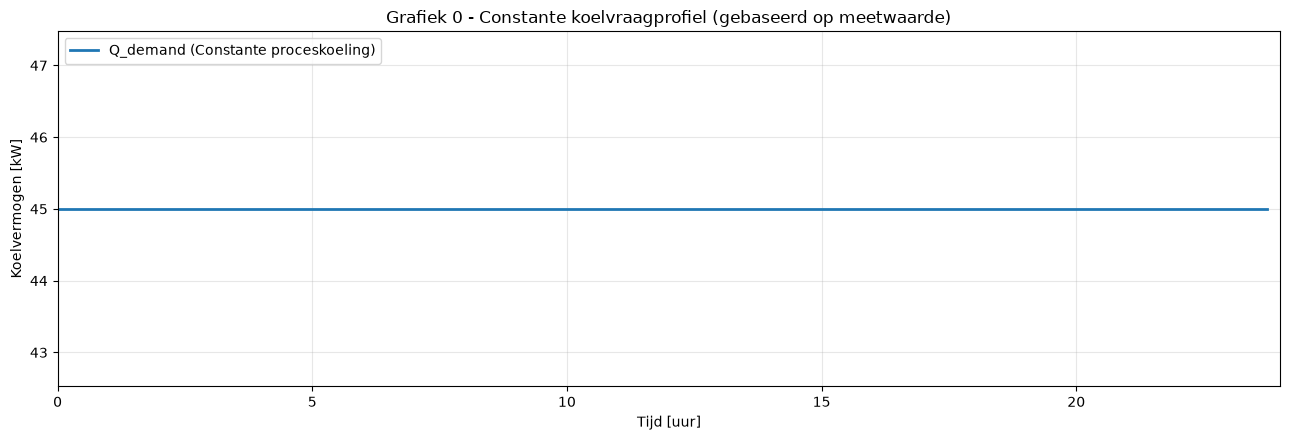

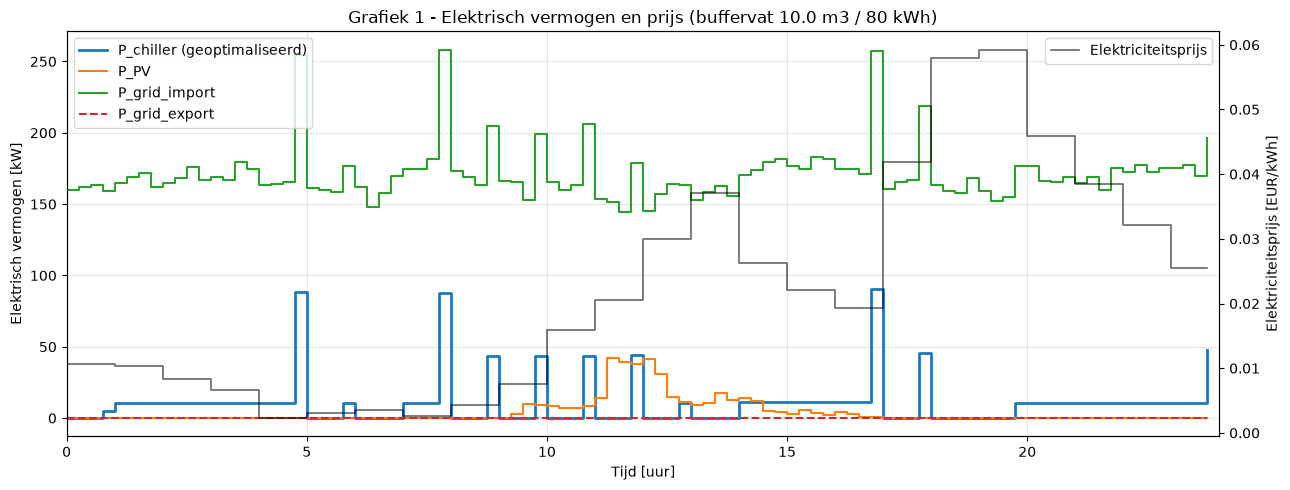

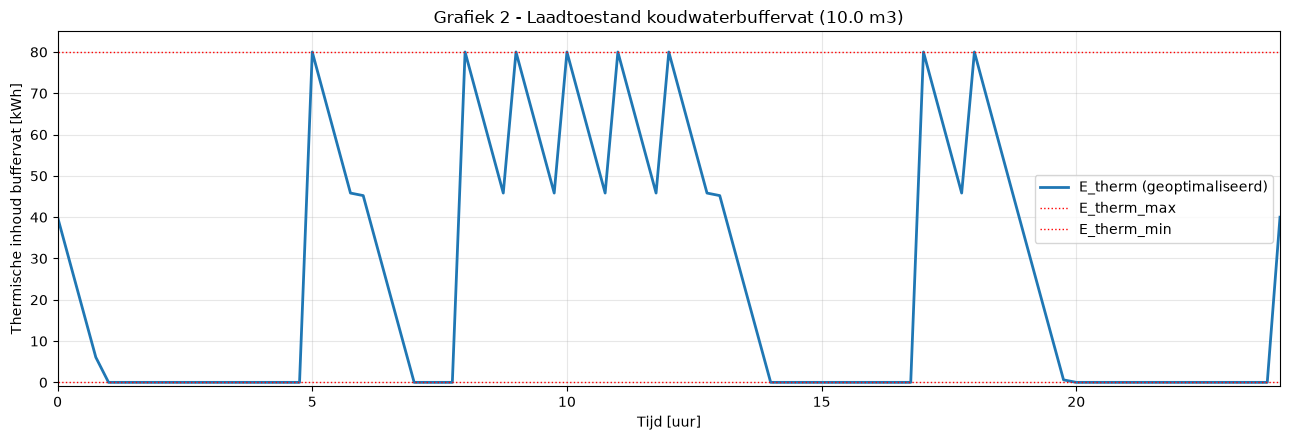

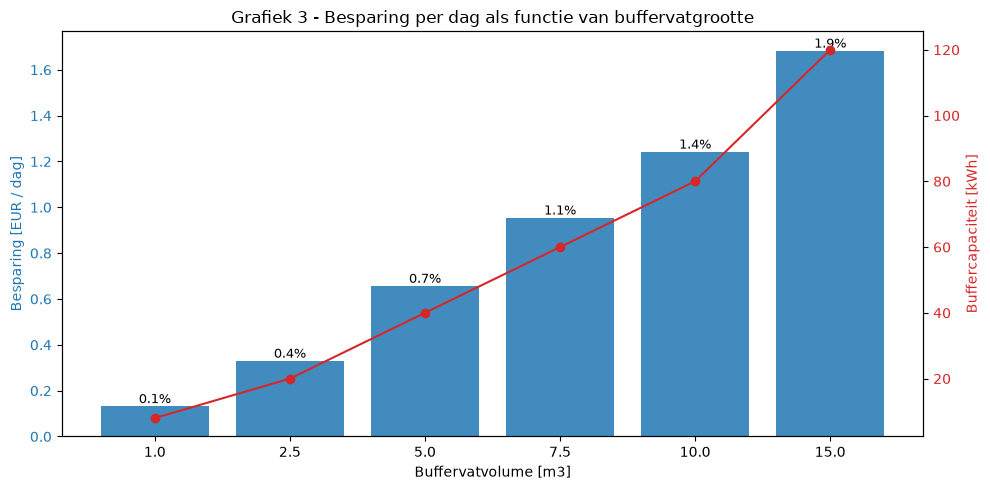

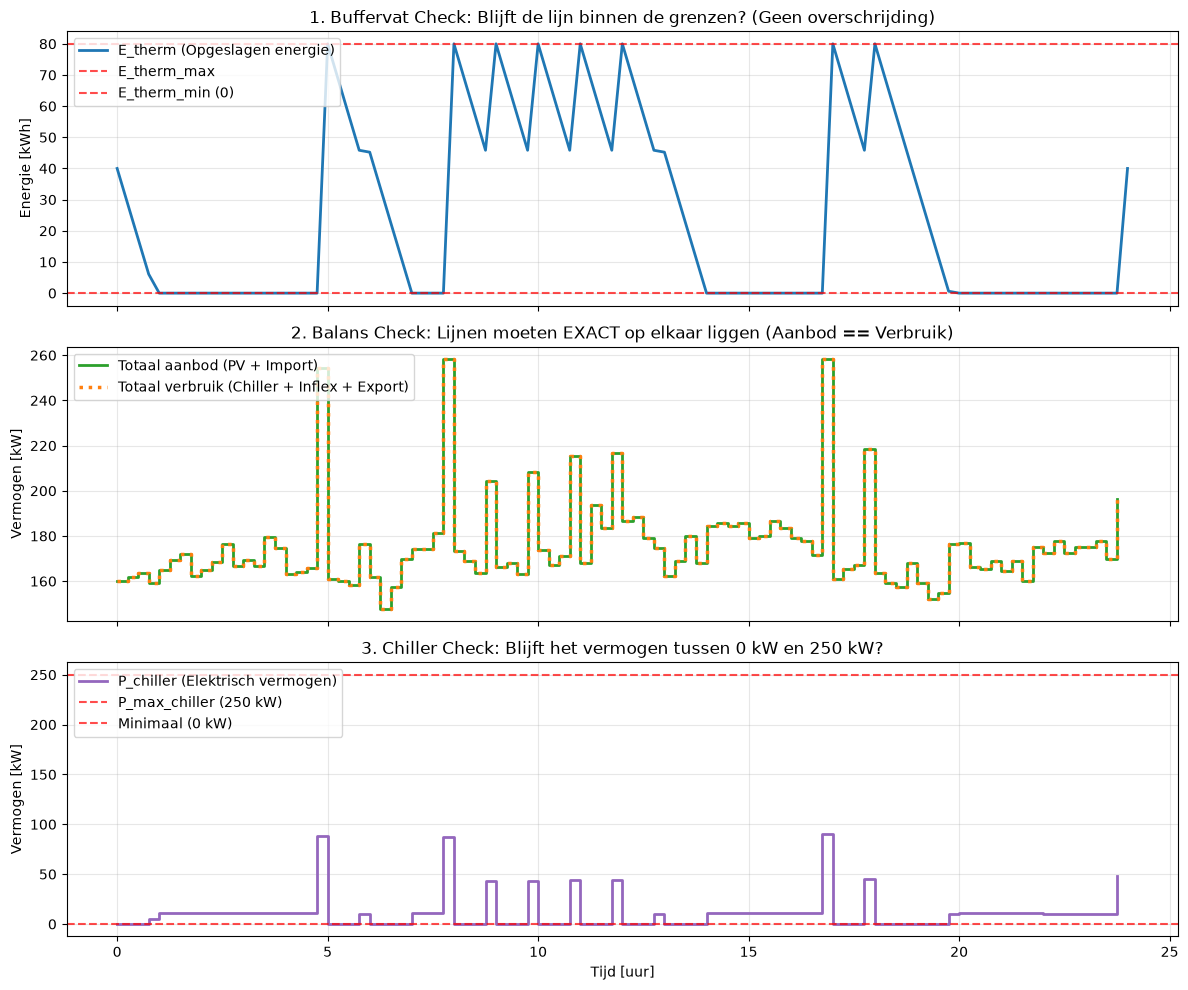

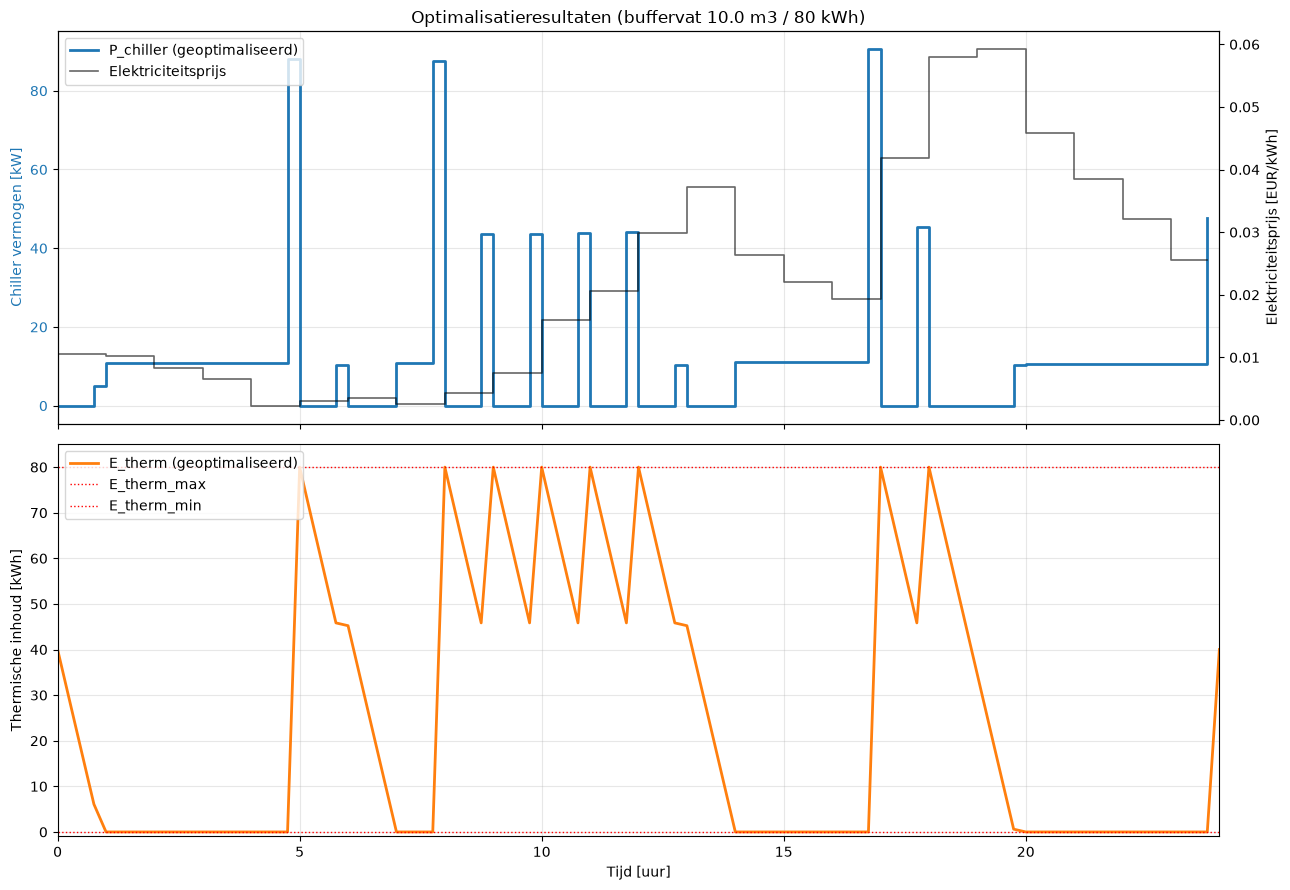

In [46]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

# Eerste 24 uur = eerste 96 kwartieren (96 * 15 min = 24 h)
N_STEPS = 96
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur, tijdstap

price = df["price"].values / 1000.0  # [EUR/kWh]
P_pv = df["pv_production"].values  # [kW]
P_inflex = df["inflex_load"].values  # [kW]
T_outdoor = df["outdoor_temperature"].values  # [degC]

time_h = np.arange(N_STEPS) * dt  # tijdas in uren (0 .. 23.75)

print(f"Data ingelezen: {N_STEPS} tijdstappen (24 uur, dt = {dt} h)")
print(f"Prijs range: {price.min():.4f} .. {price.max():.4f} EUR/kWh")
print(f"Buitentemperatuur range: {T_outdoor.min():.1f} .. {T_outdoor.max():.1f} degC")

# -----------------------------------------------------------------------------
# 2. KOELVRAAGPROFIEL (Constante proceskoeling op basis van meting)
# -----------------------------------------------------------------------------
Q_process_constant = 45.0  # kW thermisch
Q_demand = np.full(N_STEPS, Q_process_constant)

print(f"\nKoelvraagprofiel Q_demand (constante proceskoeling):")
print(f"   Q_demand : {Q_demand[0]:5.1f} kW (constant over de hele dag)")

# -----------------------------------------------------------------------------
# 3. VASTE PARAMETERS & TEMPERATUURAFHANKELIJKE COP
# -----------------------------------------------------------------------------
P_max_chiller = 250.0  # kW elektrisch, maximaal vermogen chiller

temp_points = [0, 5, 10, 15, 20, 25, 30]  # [degC]
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]  # [-]


def calculate_cop_array(T_outdoor_array, temp_points, cop_points):
  """Bepaalt de COP voor elke buitentemperatuur via lineaire interpolatie."""
  return np.interp(T_outdoor_array, temp_points, cop_points)


COP_t = calculate_cop_array(T_outdoor, temp_points, cop_points)

print(f"\nTemperatuurafhankelijke COP gedefinieerd:")
print(f"   COP range (actueel): {COP_t.min():.2f} .. {COP_t.max():.2f}")
print(f"   Gemiddelde COP:     {COP_t.mean():.2f}")

RHO_WATER = 1000.0  # kg/m3
CP_WATER = 4.186  # kJ/(kg.K)
DELTA_T = 6.0  # K
KWH_PER_M3_PHYSICAL = (RHO_WATER * CP_WATER * DELTA_T) / 3600.0
KWH_PER_M3 = 8.0  # kWh/m3 (praktische afgeronde waarde)

print(
    f"\nFysische omrekening buffervat: {KWH_PER_M3_PHYSICAL:.2f} kWh/m3"
    " (theoretisch)"
)
print(f"Gebruikte praktische omrekening: {KWH_PER_M3:.1f} kWh/m3")

eta_loss = 0.998  # stilstandsverlies-efficiëntie per tijdstap (~0.8%/uur)
E_therm_min = 0.0  # kWh, minimale thermische inhoud


# -----------------------------------------------------------------------------
# 4. OPTIMALISATIEFUNCTIE
# -----------------------------------------------------------------------------
def solve_chiller_schedule(E_therm_max, COP_array, E_therm_0=None):
  """Lost het optimalisatieprobleem op voor een gegeven buffervatcapaciteit."""
  if E_therm_0 is None:
    E_therm_0 = 0.5 * E_therm_max

  P_chiller = cp.Variable(N_STEPS, nonneg=True)
  P_grid_import = cp.Variable(N_STEPS, nonneg=True)
  P_grid_export = cp.Variable(N_STEPS, nonneg=True)
  E_therm = cp.Variable(N_STEPS + 1)

  Q_chiller = cp.multiply(COP_array, P_chiller)

  constraints = [
      P_chiller <= P_max_chiller,
      E_therm[0] == E_therm_0,
      E_therm >= E_therm_min,
      E_therm <= E_therm_max,
      E_therm[N_STEPS] == E_therm_0,  # Randvoorwaarde einde dag
      P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
  ]
  for t in range(N_STEPS):
    constraints += [
        E_therm[t + 1]
        == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
    ]

  objective = cp.Minimize(
      cp.sum(cp.multiply(P_grid_import - P_grid_export, price) * dt)
  )
  problem = cp.Problem(objective, constraints)

  try:
    cost_opt = problem.solve(solver=cp.HIGHS)
  except Exception:
    cost_opt = problem.solve()

  return {
      "status": problem.status,
      "cost": cost_opt,
      "E_therm_max": E_therm_max,
      "E_therm_0": E_therm_0,
      "P_chiller": P_chiller.value,
      "P_grid_import": P_grid_import.value,
      "P_grid_export": P_grid_export.value,
      "E_therm": E_therm.value,
  }


# -----------------------------------------------------------------------------
# 5. REFERENTIESCENARIO (geen sturing)
# -----------------------------------------------------------------------------
P_chiller_ref = np.clip(Q_demand / COP_t, 0, P_max_chiller)
net_ref = P_chiller_ref + P_inflex - P_pv
P_grid_import_ref = np.clip(net_ref, 0, None)
P_grid_export_ref = np.clip(-net_ref, 0, None)
cost_ref = np.sum((P_grid_import_ref - P_grid_export_ref) * price * dt)

print(f"\nTotale kosten ZONDER optimalisatie (referentie): {cost_ref:.2f} EUR")

# -----------------------------------------------------------------------------
# 6. BUFFERVATGROOTTE LATEN VARIËREN
# -----------------------------------------------------------------------------
buffer_volumes_m3 = [1.0, 2.5, 5.0, 7.5, 10.0, 15.0]  # m3
buffer_results = []

for V in buffer_volumes_m3:
  E_max = V * KWH_PER_M3
  res = solve_chiller_schedule(E_therm_max=E_max, COP_array=COP_t)
  saving_eur = cost_ref - res["cost"]
  saving_pct = 100 * saving_eur / cost_ref if cost_ref != 0 else np.nan
  buffer_results.append(
      {
          "volume_m3": V,
          "E_therm_max_kWh": E_max,
          "cost_opt": res["cost"],
          "saving_eur": saving_eur,
          "saving_pct": saving_pct,
          "solution": res,  # Inclusief de 'solution' sleutel
      }
  )

results_df = pd.DataFrame(
    [
        {
            "Volume [m3]": r["volume_m3"],
            "E_therm_max [kWh]": r["E_therm_max_kWh"],
            "Kosten geoptimaliseerd [EUR]": r["cost_opt"],
            "Besparing [EUR]": r["saving_eur"],
            "Besparing [%]": r["saving_pct"],
        }
        for r in buffer_results
    ]
)

print("\n" + "=" * 70)
print("RESULTATENOVERZICHT PER BUFFERVATGROOTTE")
print("=" * 70)
print(results_df.to_string(index=False, float_format=lambda x: f"{x:8.2f}"))
print("=" * 70)
print(f"Referentie (geen sturing) : {cost_ref:.2f} EUR")

# Selecteer de representatieve case vast op 10.0 m3
representative = next(r for r in buffer_results if r["volume_m3"] == 10.0)
sol = representative["solution"]

# -----------------------------------------------------------------------------
# 7. VISUALISATIES EN GRAFIEKEN (Ingesteld op 10.0 m3)
# -----------------------------------------------------------------------------

# --- Grafiek 0: Constante koelvraagprofiel ---
fig0, ax0 = plt.subplots(figsize=(13, 4.5))
ax0.step(
    time_h,
    Q_demand,
    where="post",
    color="tab:blue",
    linewidth=2,
    label="Q_demand (Constante proceskoeling)",
)
ax0.set_xlabel("Tijd [uur]")
ax0.set_ylabel("Koelvermogen [kW]")
ax0.set_xlim(0, 24)
ax0.set_title("Grafiek 0 - Constante koelvraagprofiel (gebaseerd op meetwaarde)")
ax0.legend(loc="upper left")
ax0.grid(alpha=0.3)
fig0.tight_layout()
plt.show()

# --- Grafiek 1: Elektrisch vermogen + prijs (10.0 m3) ---
fig1, ax1 = plt.subplots(figsize=(13, 5))
ax1.step(
    time_h,
    sol["P_chiller"],
    where="post",
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax1.step(
    time_h, P_pv, where="post", label="P_PV", color="tab:orange", linewidth=1.5
)
ax1.step(
    time_h,
    sol["P_grid_import"],
    where="post",
    label="P_grid_import",
    color="tab:green",
    linewidth=1.5,
)
ax1.step(
    time_h,
    sol["P_grid_export"],
    where="post",
    label="P_grid_export",
    color="tab:red",
    linewidth=1.5,
    linestyle="--",
)
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")
ax1.set_title(
    f"Grafiek 1 - Elektrisch vermogen en prijs (buffervat 10.0 m3 /"
    f" {representative['E_therm_max_kWh']:.0f} kWh)"
)
fig1.tight_layout()
plt.show()

# --- Grafiek 2: Laadtoestand buffervat (10.0 m3) ---
fig2, ax2 = plt.subplots(figsize=(13, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(
    time_h_full,
    sol["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax2.axhline(
    representative["E_therm_max_kWh"],
    color="red",
    linestyle=":",
    linewidth=1,
    label="E_therm_max",
)
ax2.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud buffervat [kWh]")
ax2.set_xlim(0, 24)
ax2.set_ylim(-1, representative["E_therm_max_kWh"] + 5)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title("Grafiek 2 - Laadtoestand koudwaterbuffervat (10.0 m3)")
fig2.tight_layout()
plt.show()

# --- Grafiek 3: Besparing als functie van buffervatgrootte ---
fig3, ax3 = plt.subplots(figsize=(10, 5))
volumes = [r["volume_m3"] for r in buffer_results]
savings_eur = [r["saving_eur"] for r in buffer_results]
savings_pct = [r["saving_pct"] for r in buffer_results]

bars = ax3.bar(
    [str(v) for v in volumes], savings_eur, color="tab:blue", alpha=0.85
)
ax3.set_xlabel("Buffervatvolume [m3]")
ax3.set_ylabel("Besparing [EUR / dag]", color="tab:blue")
ax3.tick_params(axis="y", labelcolor="tab:blue")
for bar, pct in zip(bars, savings_pct):
  ax3.text(
      bar.get_x() + bar.get_width() / 2,
      bar.get_height(),
      f"{pct:.1f}%",
      ha="center",
      va="bottom",
      fontsize=9,
  )

ax3b = ax3.twinx()
E_max_list = [r["E_therm_max_kWh"] for r in buffer_results]
ax3b.plot(
    [str(v) for v in volumes],
    E_max_list,
    color="tab:red",
    marker="o",
    label="E_therm_max [kWh]",
)
ax3b.set_ylabel("Buffercapaciteit [kWh]", color="tab:red")
ax3b.tick_params(axis="y", labelcolor="tab:red")

ax3.set_title("Grafiek 3 - Besparing per dag als functie van buffervatgrootte")
fig3.tight_layout()
plt.show()


# --- Grafiek 4: Feasibility checks ---
def plot_feasibility_checks(
    sol, time_h, P_pv, P_inflex, E_therm_max, P_max_chiller, dt
):
  fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
  time_h_full = np.arange(len(sol["E_therm"])) * dt

  # 1. Buffervat Grenzen Check
  axes[0].plot(
      time_h_full,
      sol["E_therm"],
      label="E_therm (Opgeslagen energie)",
      color="tab:blue",
      linewidth=2,
  )
  axes[0].axhline(
      E_therm_max, color="red", linestyle="--", alpha=0.7, label="E_therm_max"
  )
  axes[0].axhline(
      0, color="red", linestyle="--", alpha=0.7, label="E_therm_min (0)"
  )
  axes[0].set_ylabel("Energie [kWh]")
  axes[0].set_title(
      "1. Buffervat Check: Blijft de lijn binnen de grenzen? (Geen"
      " overschrijding)"
  )
  axes[0].legend(loc="upper left")
  axes[0].grid(alpha=0.3)

  # 2. Elektrische Balans Check
  total_supply = P_pv + sol["P_grid_import"]
  total_demand = sol["P_chiller"] + P_inflex + sol["P_grid_export"]
  axes[1].step(
      time_h,
      total_supply,
      where="post",
      label="Totaal aanbod (PV + Import)",
      color="tab:green",
      linewidth=2,
  )
  axes[1].step(
      time_h,
      total_demand,
      where="post",
      label="Totaal verbruik (Chiller + Inflex + Export)",
      color="tab:orange",
      linestyle=":",
      linewidth=2.5,
  )
  axes[1].set_ylabel("Vermogen [kW]")
  axes[1].set_title(
      "2. Balans Check: Lijnen moeten EXACT op elkaar liggen (Aanbod == Verbruik)"
  )
  axes[1].legend(loc="upper left")
  axes[1].grid(alpha=0.3)

  # 3. Chiller Vermogen Grenzen Check
  axes[2].step(
      time_h,
      sol["P_chiller"],
      where="post",
      label="P_chiller (Elektrisch vermogen)",
      color="tab:purple",
      linewidth=2,
  )
  axes[2].axhline(
      P_max_chiller,
      color="red",
      linestyle="--",
      alpha=0.7,
      label="P_max_chiller (250 kW)",
  )
  axes[2].axhline(
      0, color="red", linestyle="--", alpha=0.7, label="Minimaal (0 kW)"
  )
  axes[2].set_xlabel("Tijd [uur]")
  axes[2].set_ylabel("Vermogen [kW]")
  axes[2].set_title("3. Chiller Check: Blijft het vermogen tussen 0 kW en 250 kW?")
  axes[2].legend(loc="upper left")
  axes[2].grid(alpha=0.3)

  plt.tight_layout()
  plt.show()


plot_feasibility_checks(
    sol, time_h, P_pv, P_inflex, representative["E_therm_max_kWh"], P_max_chiller, dt
)

# --- Grafiek 5: Gecombineerde Grafiek ---
fig, (ax_top, ax_bottom) = plt.subplots(
    nrows=2, ncols=1, figsize=(13, 9), sharex=True
)

ax_top.step(
    time_h,
    sol["P_chiller"],
    where="post",
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax_top.set_ylabel("Chiller vermogen [kW]", color="tab:blue")
ax_top.tick_params(axis="y", labelcolor="tab:blue")
ax_top.set_xlim(0, 24)
ax_top.grid(alpha=0.3)

ax_top_price = ax_top.twinx()
ax_top_price.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax_top_price.set_ylabel("Elektriciteitsprijs [EUR/kWh]", color="black")
ax_top_price.tick_params(axis="y", labelcolor="black")

lines_top, labels_top = ax_top.get_legend_handles_labels()
lines_price, labels_price = ax_top_price.get_legend_handles_labels()
ax_top.legend(
    lines_top + lines_price, labels_top + labels_price, loc="upper left"
)
ax_top.set_title(
    f"Optimalisatieresultaten (buffervat 10.0 m3 /"
    f" {representative['E_therm_max_kWh']:.0f} kWh)"
)

time_h_full = np.arange(N_STEPS + 1) * dt
ax_bottom.plot(
    time_h_full,
    sol["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:orange",
    linewidth=2,
)
ax_bottom.axhline(
    representative["E_therm_max_kWh"],
    color="red",
    linestyle=":",
    linewidth=1,
    label="E_therm_max",
)
ax_bottom.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax_bottom.set_xlabel("Tijd [uur]")
ax_bottom.set_ylabel("Thermische inhoud [kWh]")
ax_bottom.set_xlim(0, 24)
ax_bottom.set_ylim(-1, representative["E_therm_max_kWh"] + 5)
ax_bottom.grid(alpha=0.3)
ax_bottom.legend(loc="upper left")

fig.tight_layout()
plt.show()

## Spotprijzen + piek

                             Baseline   Geoptimaliseerd
-------------------------------------------------------
Energiekosten [EUR]            117.30            116.75
Capaciteitskosten [EUR]         33.16             31.70
-------------------------------------------------------
Totale kosten [EUR]            150.46            148.46
-------------------------------------------------------
Totale kostenbesparing                             1.3%


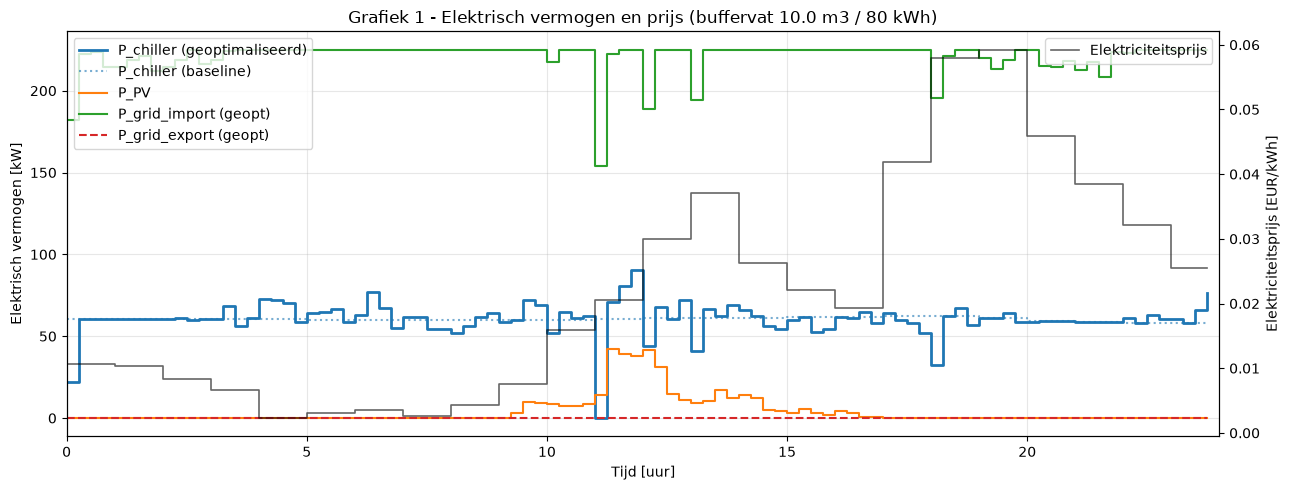

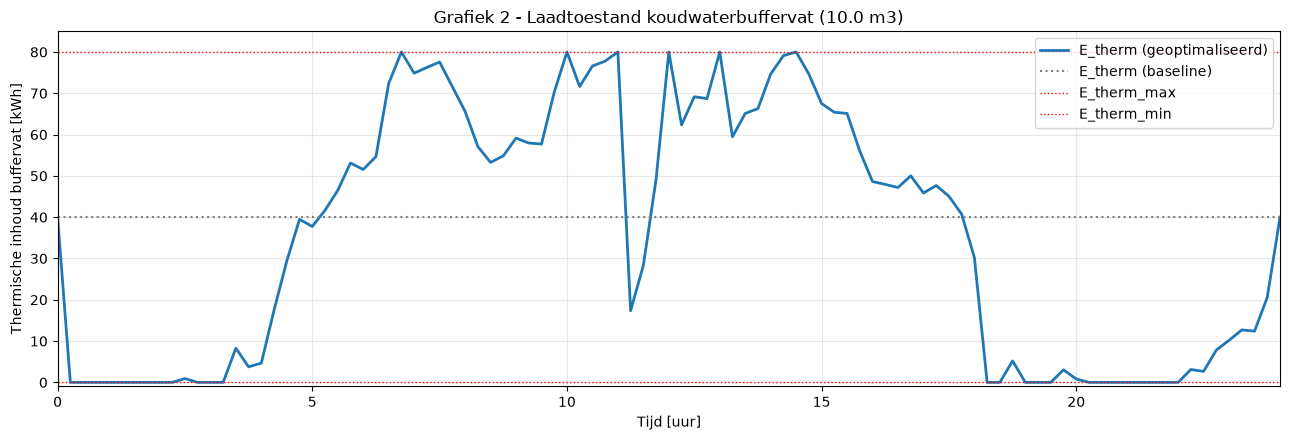

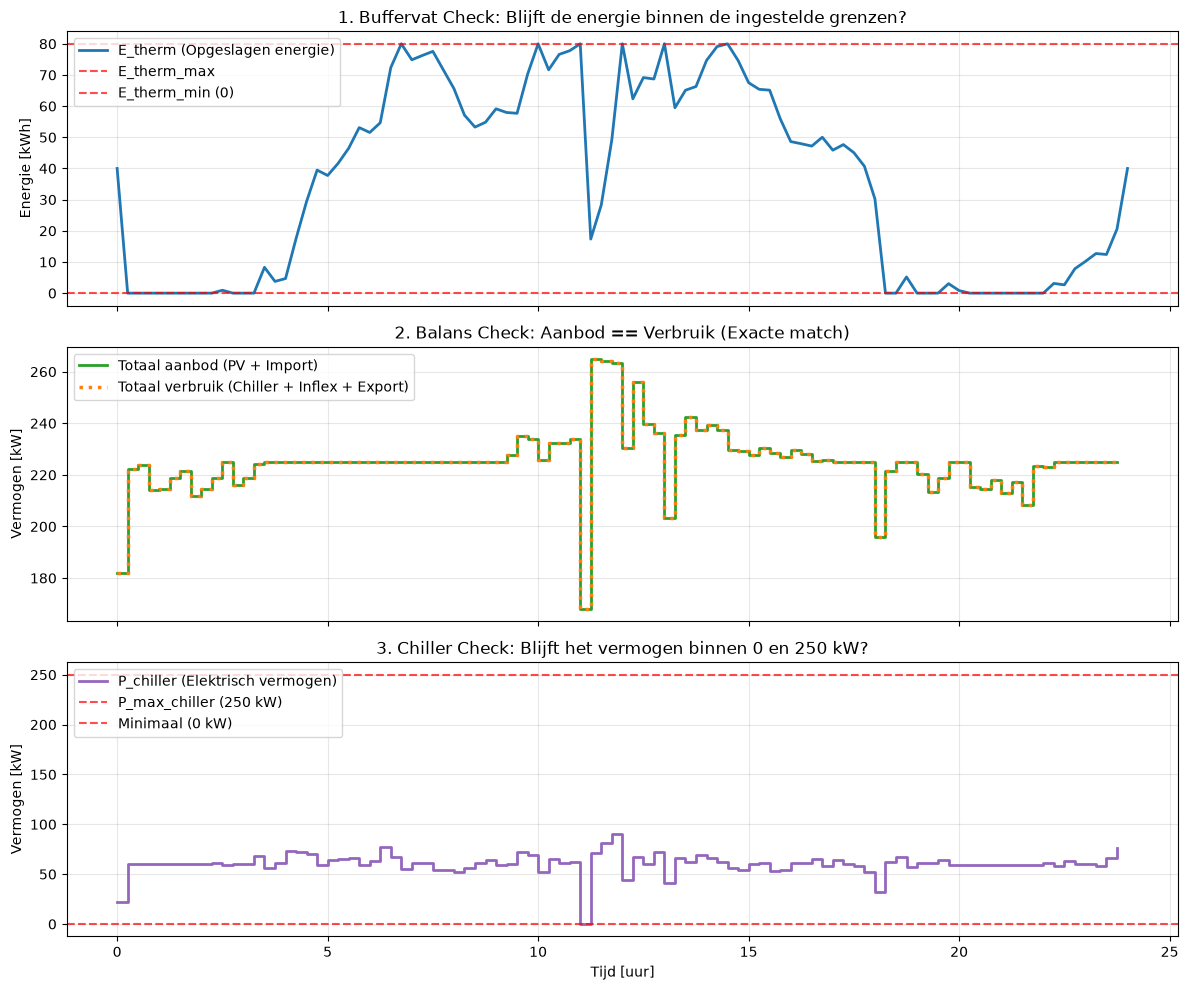

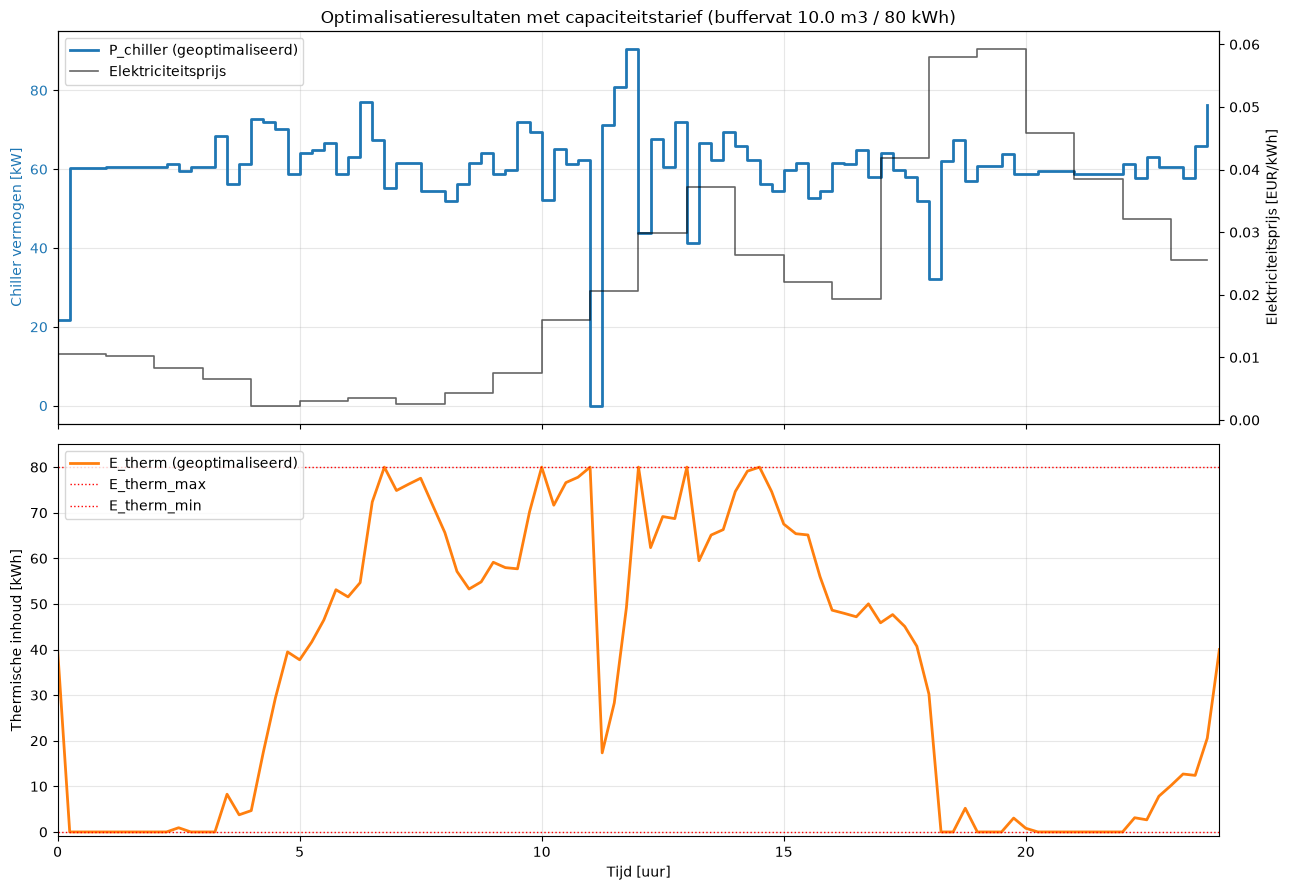

In [ ]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_STEPS = 96  # eerste 24 uur = 96 kwartieren
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur

price = df["price"].values / 1000.0  # EUR/kWh
P_pv = df["pv_production"].values  # kW
P_inflex = df["inflex_load"].values  # kW
T_outdoor = df["outdoor_temperature"].values  # degC

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. PARAMETERS
# -----------------------------------------------------------------------------
Q_demand = np.full(N_STEPS, 45)  # kW thermisch, constante proceskoeling
P_max_chiller = 250.0  # kW elektrisch

temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points)

V_buffer = 10.0  # m3
KWH_PER_M3 = 8.0
E_therm_max = V_buffer * KWH_PER_M3
E_therm_min = 0.0
eta_loss = 0.998
E_therm_0 = 0.5 * E_therm_max

DAYS_IN_MONTH = 30.0
tariff_peak_daily = 4.227 / DAYS_IN_MONTH  # EUR/kW/dag

# -----------------------------------------------------------------------------
# 3. OPTIMALISATIE & BASELINE
# -----------------------------------------------------------------------------


def solve_optimized():
  P_chiller = cp.Variable(N_STEPS, nonneg=True)
  P_grid_import = cp.Variable(N_STEPS, nonneg=True)
  P_grid_export = cp.Variable(N_STEPS, nonneg=True)
  E_therm = cp.Variable(N_STEPS + 1)
  P_peak = cp.Variable(nonneg=True)

  Q_chiller = cp.multiply(COP_t, P_chiller)

  constraints = [
      P_chiller <= P_max_chiller,
      E_therm[0] == E_therm_0,
      E_therm >= E_therm_min,
      E_therm <= E_therm_max,
      E_therm[N_STEPS] == E_therm_0,
      P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
      *[P_peak >= P_grid_import[t] for t in range(N_STEPS)],
  ]
  for t in range(N_STEPS):
    constraints += [
        E_therm[t + 1]
        == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
    ]

  energy_cost = cp.sum(cp.multiply(P_grid_import - P_grid_export, price) * dt)
  capacity_cost = P_peak * tariff_peak_daily

  problem = cp.Problem(cp.Minimize(energy_cost + capacity_cost), constraints)
  problem.solve(solver=cp.HIGHS)

  return {
      "P_chiller": P_chiller.value,
      "P_grid_import": P_grid_import.value,
      "P_grid_export": P_grid_export.value,
      "E_therm": E_therm.value,
      "energy_cost": energy_cost.value,
      "capacity_cost": capacity_cost.value,
      "cost": problem.value,
  }


def solve_baseline():
  P_chiller_bl = Q_demand / COP_t  # chiller volgt vraag direct
  net_bl = P_chiller_bl + P_inflex - P_pv
  P_grid_import_bl = np.maximum(net_bl, 0.0)
  P_grid_export_bl = np.maximum(-net_bl, 0.0)

  E_therm_bl = np.full(
      N_STEPS + 1, E_therm_0
  )  # vat blijft op startniveau

  P_peak_bl = P_grid_import_bl.max()
  energy_cost_bl = np.sum((P_grid_import_bl - P_grid_export_bl) * price) * dt
  capacity_cost_bl = P_peak_bl * tariff_peak_daily

  return {
      "P_chiller": P_chiller_bl,
      "P_grid_import": P_grid_import_bl,
      "P_grid_export": P_grid_export_bl,
      "E_therm": E_therm_bl,
      "energy_cost": energy_cost_bl,
      "capacity_cost": capacity_cost_bl,
      "cost": energy_cost_bl + capacity_cost_bl,
  }


opt = solve_optimized()
base = solve_baseline()

# -----------------------------------------------------------------------------
# 4. KOSTENVERGELIJKING
# -----------------------------------------------------------------------------
savings_pct = 100.0 * (base["cost"] - opt["cost"]) / base["cost"]

print(f"{'':25}{'Baseline':>12}{'Geoptimaliseerd':>18}")
print("-" * 55)
print(
    f"{'Energiekosten [EUR]':25}{base['energy_cost']:>12.2f}{opt['energy_cost']:>18.2f}"
)
print(
    f"{'Capaciteitskosten [EUR]':25}{base['capacity_cost']:>12.2f}{opt['capacity_cost']:>18.2f}"
)
print("-" * 55)
print(f"{'Totale kosten [EUR]':25}{base['cost']:>12.2f}{opt['cost']:>18.2f}")
print("-" * 55)
print(f"{'Totale kostenbesparing':25}{'':>12}{savings_pct:>17.1f}%")

# -----------------------------------------------------------------------------
# 5. VISUALISATIES EN GRAFIEKEN
# -----------------------------------------------------------------------------

# --- Grafiek 1: Elektrisch vermogen + prijs ---
fig1, ax1 = plt.subplots(figsize=(13, 5))
ax1.step(
    time_h,
    opt["P_chiller"],
    where="post",
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax1.step(
    time_h,
    base["P_chiller"],
    where="post",
    label="P_chiller (baseline)",
    color="tab:blue",
    linestyle=":",
    alpha=0.6,
    linewidth=1.5,
)
ax1.step(
    time_h, P_pv, where="post", label="P_PV", color="tab:orange", linewidth=1.5
)
ax1.step(
    time_h,
    opt["P_grid_import"],
    where="post",
    label="P_grid_import (geopt)",
    color="tab:green",
    linewidth=1.5,
)
ax1.step(
    time_h,
    opt["P_grid_export"],
    where="post",
    label="P_grid_export (geopt)",
    color="tab:red",
    linewidth=1.5,
    linestyle="--",
)
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")
ax1.set_title(
    f"Grafiek 1 - Elektrisch vermogen en prijs (buffervat {V_buffer} m3 /"
    f" {E_therm_max:.0f} kWh)"
)
fig1.tight_layout()
plt.show()

# --- Grafiek 2: Laadtoestand buffervat ---
fig2, ax2 = plt.subplots(figsize=(13, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(
    time_h_full,
    opt["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax2.plot(
    time_h_full,
    base["E_therm"],
    label="E_therm (baseline)",
    color="tab:gray",
    linestyle=":",
    linewidth=1.5,
)
ax2.axhline(
    E_therm_max, color="red", linestyle=":", linewidth=1, label="E_therm_max"
)
ax2.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud buffervat [kWh]")
ax2.set_xlim(0, 24)
ax2.set_ylim(-1, E_therm_max + 5)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title(f"Grafiek 2 - Laadtoestand koudwaterbuffervat ({V_buffer} m3)")
fig2.tight_layout()
plt.show()

# --- Grafiek 3: Haalbaarheidschecks ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(
    time_h_full,
    opt["E_therm"],
    label="E_therm (Opgeslagen energie)",
    color="tab:blue",
    linewidth=2,
)
axes[0].axhline(
    E_therm_max, color="red", linestyle="--", alpha=0.7, label="E_therm_max"
)
axes[0].axhline(
    0, color="red", linestyle="--", alpha=0.7, label="E_therm_min (0)"
)
axes[0].set_ylabel("Energie [kWh]")
axes[0].set_title(
    "1. Buffervat Check: Blijft de energie binnen de ingestelde grenzen?"
)
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)

total_supply = P_pv + opt["P_grid_import"]
total_demand = opt["P_chiller"] + P_inflex + opt["P_grid_export"]
axes[1].step(
    time_h,
    total_supply,
    where="post",
    label="Totaal aanbod (PV + Import)",
    color="tab:green",
    linewidth=2,
)
axes[1].step(
    time_h,
    total_demand,
    where="post",
    label="Totaal verbruik (Chiller + Inflex + Export)",
    color="tab:orange",
    linestyle=":",
    linewidth=2.5,
)
axes[1].set_ylabel("Vermogen [kW]")
axes[1].set_title("2. Balans Check: Aanbod == Verbruik (Exacte match)")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.3)

axes[2].step(
    time_h,
    opt["P_chiller"],
    where="post",
    label="P_chiller (Elektrisch vermogen)",
    color="tab:purple",
    linewidth=2,
)
axes[2].axhline(
    P_max_chiller,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="P_max_chiller (250 kW)",
)
axes[2].axhline(0, color="red", linestyle="--", alpha=0.7, label="Minimaal (0 kW)")
axes[2].set_xlabel("Tijd [uur]")
axes[2].set_ylabel("Vermogen [kW]")
axes[2].set_title("3. Chiller Check: Blijft het vermogen binnen 0 en 250 kW?")
axes[2].legend(loc="upper left")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Grafiek 4: Gecombineerde Grafiek ---
fig, (ax_top, ax_bottom) = plt.subplots(
    nrows=2, ncols=1, figsize=(13, 9), sharex=True
)

ax_top.step(
    time_h,
    opt["P_chiller"],
    where="post",
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax_top.set_ylabel("Chiller vermogen [kW]", color="tab:blue")
ax_top.tick_params(axis="y", labelcolor="tab:blue")
ax_top.set_xlim(0, 24)
ax_top.grid(alpha=0.3)

ax_top_price = ax_top.twinx()
ax_top_price.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax_top_price.set_ylabel("Elektriciteitsprijs [EUR/kWh]", color="black")
ax_top_price.tick_params(axis="y", labelcolor="black")

lines_top, labels_top = ax_top.get_legend_handles_labels()
lines_price, labels_price = ax_top_price.get_legend_handles_labels()
ax_top.legend(
    lines_top + lines_price, labels_top + labels_price, loc="upper left"
)
ax_top.set_title(
    f"Optimalisatieresultaten met capaciteitstarief (buffervat {V_buffer} m3 /"
    f" {E_therm_max:.0f} kWh)"
)

ax_bottom.plot(
    time_h_full,
    opt["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:orange",
    linewidth=2,
)
ax_bottom.axhline(
    E_therm_max, color="red", linestyle=":", linewidth=1, label="E_therm_max"
)
ax_bottom.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax_bottom.set_xlabel("Tijd [uur]")
ax_bottom.set_ylabel("Thermische inhoud [kWh]")
ax_bottom.set_xlim(0, 24)
ax_bottom.set_ylim(-1, E_therm_max + 5)
ax_bottom.grid(alpha=0.3)
ax_bottom.legend(loc="upper left")

fig.tight_layout()
plt.show()

# Implementatie volledige kostenfunctie

                             Baseline   Geoptimaliseerd
-------------------------------------------------------
Spotkosten [EUR]                90.91             90.06
Energiekosten [EUR]            128.29            128.31
Piekkosten [EUR]               508.61            507.60
-------------------------------------------------------
Totale kosten [EUR]            727.81            725.98
-------------------------------------------------------
Totale kostenbesparing                             0.3%
Gerealiseerde piek [kW]        184.33            176.96


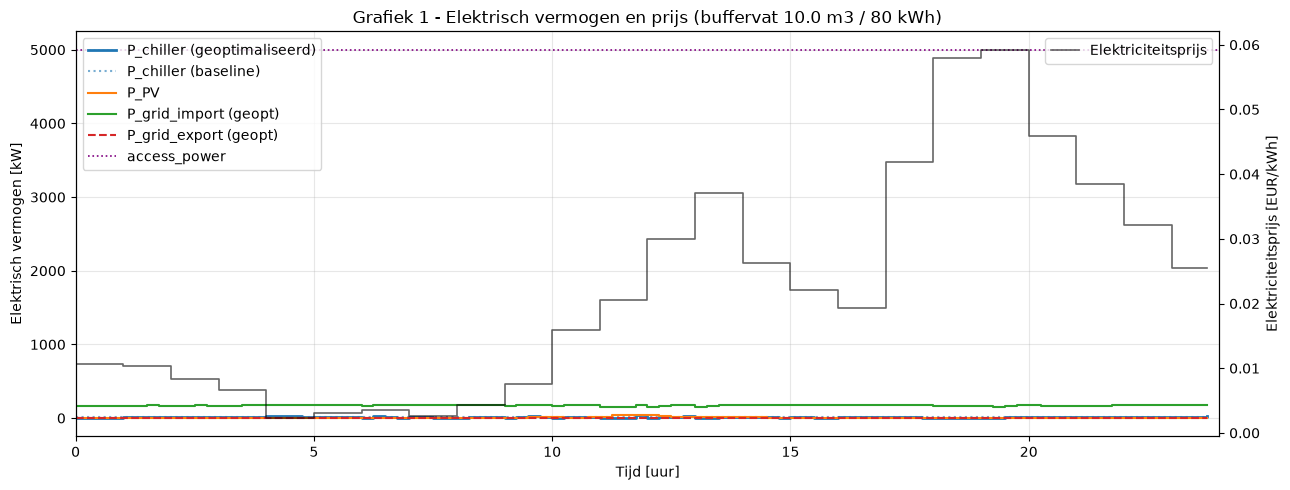

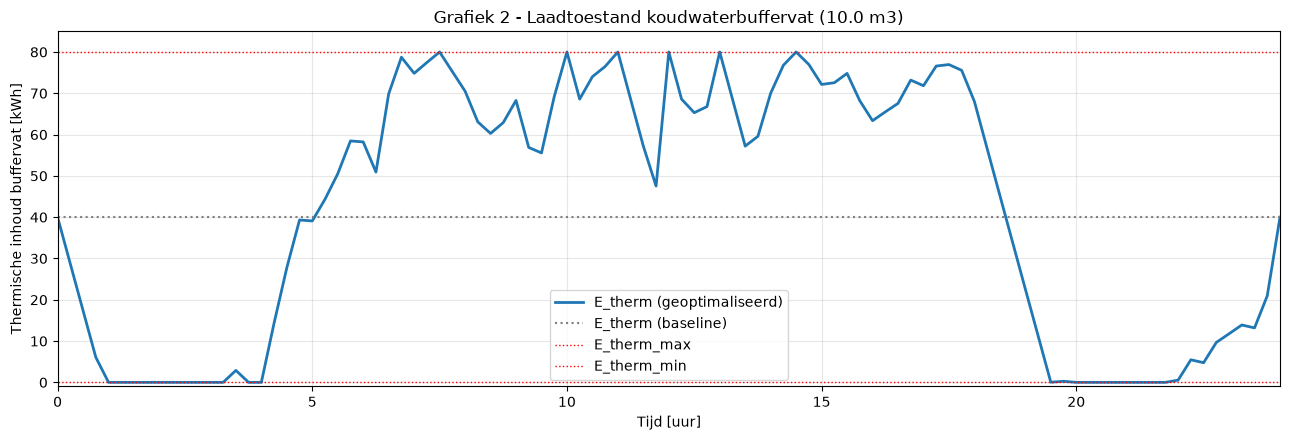

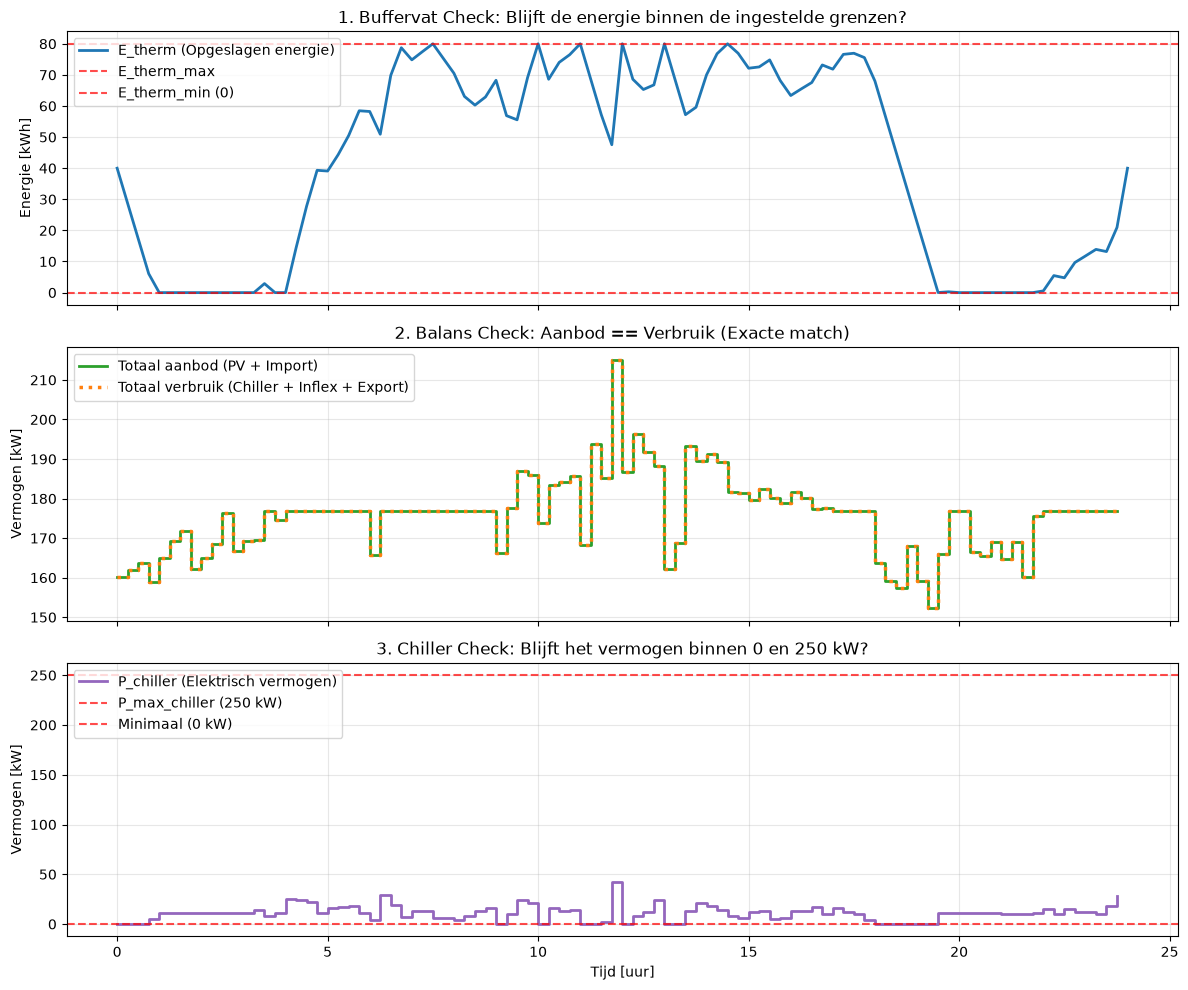

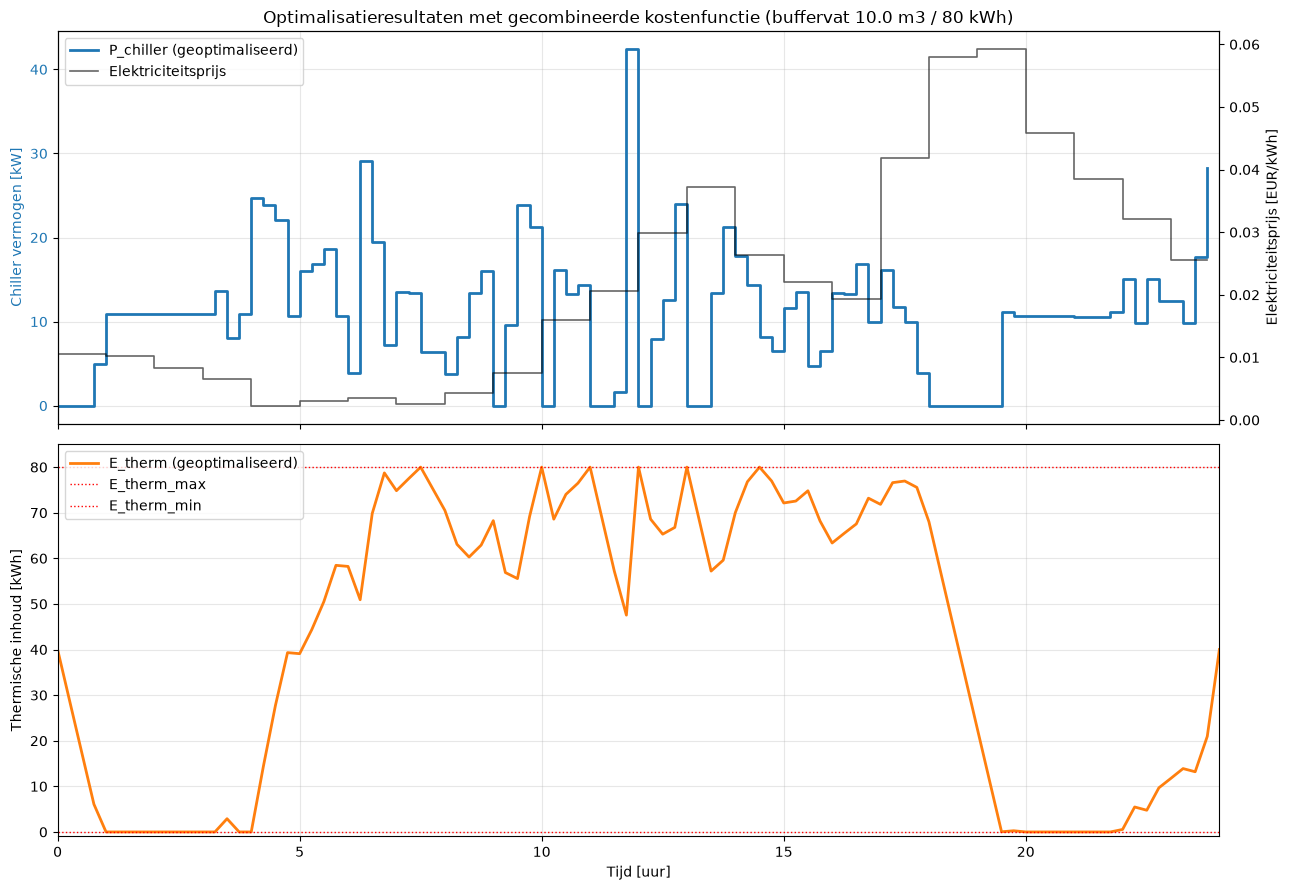

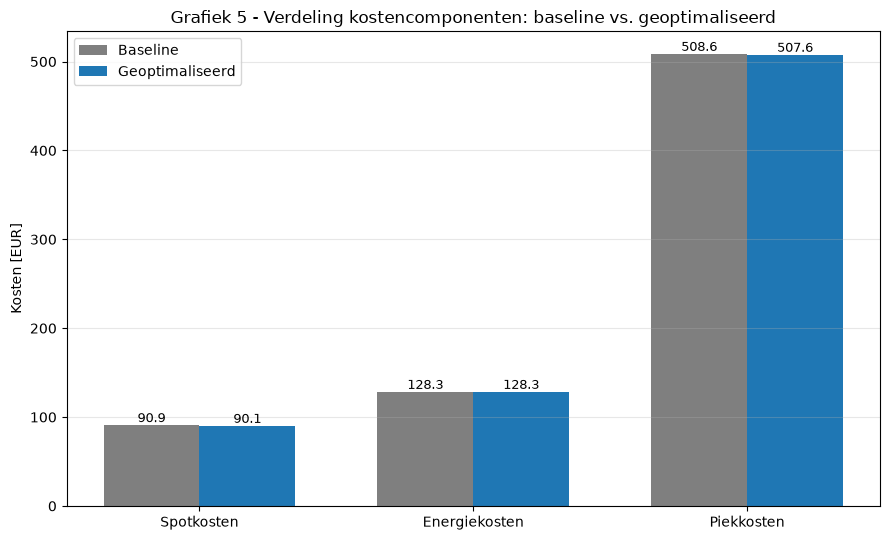

In [56]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_STEPS = 96  # eerste 24 uur = 96 kwartieren
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur

price = df["price"].values / 1000.0  # EUR/kWh
P_pv = df["pv_production"].values  # kW
P_inflex = df["inflex_load"].values  # kW
T_outdoor = df["outdoor_temperature"].values  # degC

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. PARAMETERS
# -----------------------------------------------------------------------------
Q_demand = np.full(N_STEPS, 45.0)  # kW thermisch, constante proceskoeling
P_max_chiller = 250.0  # kW elektrisch

temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points)

V_buffer = 10.0  # m3
KWH_PER_M3 = 8.0
E_therm_max = V_buffer * KWH_PER_M3
E_therm_min = 0.0
eta_loss = 0.998
E_therm_0 = 0.5 * E_therm_max

# --- Parameters gecombineerde kostenfunctie ---
vaste_kosten = 30.7903/1000          # EUR/kWh, vaste opslag/heffing op geimporteerde energie
netverliesfactor = 0.0185    # fractie netverliezen, toegepast op geimporteerde energie

access_power = 5000   # kW, gecontracteerd (afgenomen) vermogen
excess_prijs = 2.9975458 / 31     # EUR/kW/dag, vaste kosten voor gecontracteerd vermogen
piekprijs = 4.2269465 / 31          # EUR/kW/dag, kosten voor de gerealiseerde piek
prijs_boete = 4.4963187 /31       # EUR/kW/dag, boetetarief boven het gecontracteerde vermogen

# -----------------------------------------------------------------------------
# 3. OPTIMALISATIE & BASELINE
# -----------------------------------------------------------------------------


# -----------------------------------------------------------------------------
# AANGEPASTE KOSTENFUNCTIE (Volumegewogen netverliezen)
# -----------------------------------------------------------------------------
def kosten_componenten(P_grid_import, P_grid_export, gebruik_cvxpy):
    """Berekent de drie kostencomponenten (spot, energie, piek)."""
    if gebruik_cvxpy:
        # Netto spotkosten (import - export)
        spotkosten = cp.sum(cp.multiply(P_grid_import - P_grid_export, price)) * dt

        # Import-spotkosten (nodig voor exacte netverliezen op import)
        import_spotkosten = cp.sum(cp.multiply(P_grid_import, price)) * dt

        # Energiekosten = vaste toeslag per kWh + exacte netverliezen over de geïmporteerde waarde
        energiekosten = (
            cp.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )

        piek = cp.max(P_grid_import)
        Ppiekbovenaccess = cp.pos(piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )
    else:
        spotkosten = np.sum((P_grid_import - P_grid_export) * price) * dt
        import_spotkosten = np.sum(P_grid_import * price) * dt

        energiekosten = (
            np.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )

        piek = np.max(P_grid_import)
        Ppiekbovenaccess = max(0.0, piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )

    return spotkosten, energiekosten, piekkosten, piek


def solve_optimized():
  P_chiller = cp.Variable(N_STEPS, nonneg=True)
  P_grid_import = cp.Variable(N_STEPS, nonneg=True)
  P_grid_export = cp.Variable(N_STEPS, nonneg=True)
  E_therm = cp.Variable(N_STEPS + 1)

  Q_chiller = cp.multiply(COP_t, P_chiller)

  constraints = [
      P_chiller <= P_max_chiller,
      E_therm[0] == E_therm_0,
      E_therm >= E_therm_min,
      E_therm <= E_therm_max,
      E_therm[N_STEPS] == E_therm_0,
      P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
  ]
  for t in range(N_STEPS):
    constraints += [
        E_therm[t + 1]
        == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
    ]

  spotkosten, energiekosten, piekkosten, piek = kosten_componenten(
      P_grid_import, P_grid_export, gebruik_cvxpy=True
  )

  problem = cp.Problem(
      cp.Minimize(spotkosten + energiekosten + piekkosten), constraints
  )
  problem.solve(solver=cp.HIGHS)

  return {
      "P_chiller": P_chiller.value,
      "P_grid_import": P_grid_import.value,
      "P_grid_export": P_grid_export.value,
      "E_therm": E_therm.value,
      "spotkosten": spotkosten.value,
      "energiekosten": energiekosten.value,
      "piekkosten": piekkosten.value,
      "piek": piek.value,
      "cost": problem.value,
  }


def solve_baseline():
  P_chiller_bl = Q_demand / COP_t  # chiller volgt vraag direct
  net_bl = P_chiller_bl + P_inflex - P_pv
  P_grid_import_bl = np.maximum(net_bl, 0.0)
  P_grid_export_bl = np.maximum(-net_bl, 0.0)

  E_therm_bl = np.full(
      N_STEPS + 1, E_therm_0
  )  # vat blijft op startniveau

  spotkosten_bl, energiekosten_bl, piekkosten_bl, piek_bl = kosten_componenten(
      P_grid_import_bl, P_grid_export_bl, gebruik_cvxpy=False
  )

  return {
      "P_chiller": P_chiller_bl,
      "P_grid_import": P_grid_import_bl,
      "P_grid_export": P_grid_export_bl,
      "E_therm": E_therm_bl,
      "spotkosten": spotkosten_bl,
      "energiekosten": energiekosten_bl,
      "piekkosten": piekkosten_bl,
      "piek": piek_bl,
      "cost": spotkosten_bl + energiekosten_bl + piekkosten_bl,
  }


opt = solve_optimized()
base = solve_baseline()

# -----------------------------------------------------------------------------
# 4. KOSTENVERGELIJKING
# -----------------------------------------------------------------------------
savings_pct = 100.0 * (base["cost"] - opt["cost"]) / base["cost"]

print(f"{'':25}{'Baseline':>12}{'Geoptimaliseerd':>18}")
print("-" * 55)
print(f"{'Spotkosten [EUR]':25}{base['spotkosten']:>12.2f}{opt['spotkosten']:>18.2f}")
print(f"{'Energiekosten [EUR]':25}{base['energiekosten']:>12.2f}{opt['energiekosten']:>18.2f}")
print(f"{'Piekkosten [EUR]':25}{base['piekkosten']:>12.2f}{opt['piekkosten']:>18.2f}")
print("-" * 55)
print(f"{'Totale kosten [EUR]':25}{base['cost']:>12.2f}{opt['cost']:>18.2f}")
print("-" * 55)
print(f"{'Totale kostenbesparing':25}{'':>12}{savings_pct:>17.1f}%")
print(f"{'Gerealiseerde piek [kW]':25}{base['piek']:>12.2f}{opt['piek']:>18.2f}")

# -----------------------------------------------------------------------------
# 5. VISUALISATIES EN GRAFIEKEN
# -----------------------------------------------------------------------------

# --- Grafiek 1: Elektrisch vermogen + prijs ---
fig1, ax1 = plt.subplots(figsize=(13, 5))
ax1.step(
    time_h,
    opt["P_chiller"],
    where="post",
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax1.step(
    time_h,
    base["P_chiller"],
    where="post",
    label="P_chiller (baseline)",
    color="tab:blue",
    linestyle=":",
    alpha=0.6,
    linewidth=1.5,
)
ax1.step(
    time_h, P_pv, where="post", label="P_PV", color="tab:orange", linewidth=1.5
)
ax1.step(
    time_h,
    opt["P_grid_import"],
    where="post",
    label="P_grid_import (geopt)",
    color="tab:green",
    linewidth=1.5,
)
ax1.step(
    time_h,
    opt["P_grid_export"],
    where="post",
    label="P_grid_export (geopt)",
    color="tab:red",
    linewidth=1.5,
    linestyle="--",
)
ax1.axhline(
    access_power, color="purple", linestyle=":", linewidth=1.2, label="access_power"
)
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, 24)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1b.legend(loc="upper right")
ax1.set_title(
    f"Grafiek 1 - Elektrisch vermogen en prijs (buffervat {V_buffer} m3 /"
    f" {E_therm_max:.0f} kWh)"
)
fig1.tight_layout()
plt.show()

# --- Grafiek 2: Laadtoestand buffervat ---
fig2, ax2 = plt.subplots(figsize=(13, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(
    time_h_full,
    opt["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax2.plot(
    time_h_full,
    base["E_therm"],
    label="E_therm (baseline)",
    color="tab:gray",
    linestyle=":",
    linewidth=1.5,
)
ax2.axhline(
    E_therm_max, color="red", linestyle=":", linewidth=1, label="E_therm_max"
)
ax2.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud buffervat [kWh]")
ax2.set_xlim(0, 24)
ax2.set_ylim(-1, E_therm_max + 5)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title(f"Grafiek 2 - Laadtoestand koudwaterbuffervat ({V_buffer} m3)")
fig2.tight_layout()
plt.show()

# --- Grafiek 3: Haalbaarheidschecks ---
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(
    time_h_full,
    opt["E_therm"],
    label="E_therm (Opgeslagen energie)",
    color="tab:blue",
    linewidth=2,
)
axes[0].axhline(
    E_therm_max, color="red", linestyle="--", alpha=0.7, label="E_therm_max"
)
axes[0].axhline(
    0, color="red", linestyle="--", alpha=0.7, label="E_therm_min (0)"
)
axes[0].set_ylabel("Energie [kWh]")
axes[0].set_title(
    "1. Buffervat Check: Blijft de energie binnen de ingestelde grenzen?"
)
axes[0].legend(loc="upper left")
axes[0].grid(alpha=0.3)

total_supply = P_pv + opt["P_grid_import"]
total_demand = opt["P_chiller"] + P_inflex + opt["P_grid_export"]
axes[1].step(
    time_h,
    total_supply,
    where="post",
    label="Totaal aanbod (PV + Import)",
    color="tab:green",
    linewidth=2,
)
axes[1].step(
    time_h,
    total_demand,
    where="post",
    label="Totaal verbruik (Chiller + Inflex + Export)",
    color="tab:orange",
    linestyle=":",
    linewidth=2.5,
)
axes[1].set_ylabel("Vermogen [kW]")
axes[1].set_title("2. Balans Check: Aanbod == Verbruik (Exacte match)")
axes[1].legend(loc="upper left")
axes[1].grid(alpha=0.3)

axes[2].step(
    time_h,
    opt["P_chiller"],
    where="post",
    label="P_chiller (Elektrisch vermogen)",
    color="tab:purple",
    linewidth=2,
)
axes[2].axhline(
    P_max_chiller,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="P_max_chiller (250 kW)",
)
axes[2].axhline(0, color="red", linestyle="--", alpha=0.7, label="Minimaal (0 kW)")
axes[2].set_xlabel("Tijd [uur]")
axes[2].set_ylabel("Vermogen [kW]")
axes[2].set_title("3. Chiller Check: Blijft het vermogen binnen 0 en 250 kW?")
axes[2].legend(loc="upper left")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# --- Grafiek 4: Gecombineerde Grafiek ---
fig, (ax_top, ax_bottom) = plt.subplots(
    nrows=2, ncols=1, figsize=(13, 9), sharex=True
)

ax_top.step(
    time_h,
    opt["P_chiller"],
    where="post",
    label="P_chiller (geoptimaliseerd)",
    color="tab:blue",
    linewidth=2,
)
ax_top.set_ylabel("Chiller vermogen [kW]", color="tab:blue")
ax_top.tick_params(axis="y", labelcolor="tab:blue")
ax_top.set_xlim(0, 24)
ax_top.grid(alpha=0.3)

ax_top_price = ax_top.twinx()
ax_top_price.step(
    time_h,
    price,
    where="post",
    color="black",
    linewidth=1.2,
    alpha=0.6,
    label="Elektriciteitsprijs",
)
ax_top_price.set_ylabel("Elektriciteitsprijs [EUR/kWh]", color="black")
ax_top_price.tick_params(axis="y", labelcolor="black")

lines_top, labels_top = ax_top.get_legend_handles_labels()
lines_price, labels_price = ax_top_price.get_legend_handles_labels()
ax_top.legend(
    lines_top + lines_price, labels_top + labels_price, loc="upper left"
)
ax_top.set_title(
    f"Optimalisatieresultaten met gecombineerde kostenfunctie (buffervat {V_buffer} m3 /"
    f" {E_therm_max:.0f} kWh)"
)

ax_bottom.plot(
    time_h_full,
    opt["E_therm"],
    label="E_therm (geoptimaliseerd)",
    color="tab:orange",
    linewidth=2,
)
ax_bottom.axhline(
    E_therm_max, color="red", linestyle=":", linewidth=1, label="E_therm_max"
)
ax_bottom.axhline(
    E_therm_min, color="red", linestyle=":", linewidth=1, label="E_therm_min"
)
ax_bottom.set_xlabel("Tijd [uur]")
ax_bottom.set_ylabel("Thermische inhoud [kWh]")
ax_bottom.set_xlim(0, 24)
ax_bottom.set_ylim(-1, E_therm_max + 5)
ax_bottom.grid(alpha=0.3)
ax_bottom.legend(loc="upper left")

fig.tight_layout()
plt.show()

# --- Grafiek 5: Verdeling kostencomponenten (baseline vs. geoptimaliseerd) ---
componenten = ["Spotkosten", "Energiekosten", "Piekkosten"]
waarden_base = [base["spotkosten"], base["energiekosten"], base["piekkosten"]]
waarden_opt = [opt["spotkosten"], opt["energiekosten"], opt["piekkosten"]]

x = np.arange(len(componenten))
breedte = 0.35

fig5, ax5 = plt.subplots(figsize=(9, 5.5))
bars_base = ax5.bar(
    x - breedte / 2, waarden_base, breedte, label="Baseline", color="tab:gray"
)
bars_opt = ax5.bar(
    x + breedte / 2, waarden_opt, breedte, label="Geoptimaliseerd", color="tab:blue"
)

for bars in (bars_base, bars_opt):
  for bar in bars:
    ax5.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{bar.get_height():.1f}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

ax5.set_xticks(x)
ax5.set_xticklabels(componenten)
ax5.set_ylabel("Kosten [EUR]")
ax5.set_title("Grafiek 5 - Verdeling kostencomponenten: baseline vs. geoptimaliseerd")
ax5.legend()
ax5.grid(axis="y", alpha=0.3)
fig5.tight_layout()
plt.show()

## Over hele maand ipv over een dag: 

                             Baseline   Geoptimaliseerd
-------------------------------------------------------
Spotkosten [EUR]             38792.48          38717.07
Energiekosten [EUR]          10955.94          10955.13
Piekkosten [EUR]             18005.72          17766.42
-------------------------------------------------------
Totale kosten [EUR]          67754.13          67438.62
-------------------------------------------------------
Totale kostenbesparing                             0.5%
Gerealiseerde piek [kW]        713.99            657.37


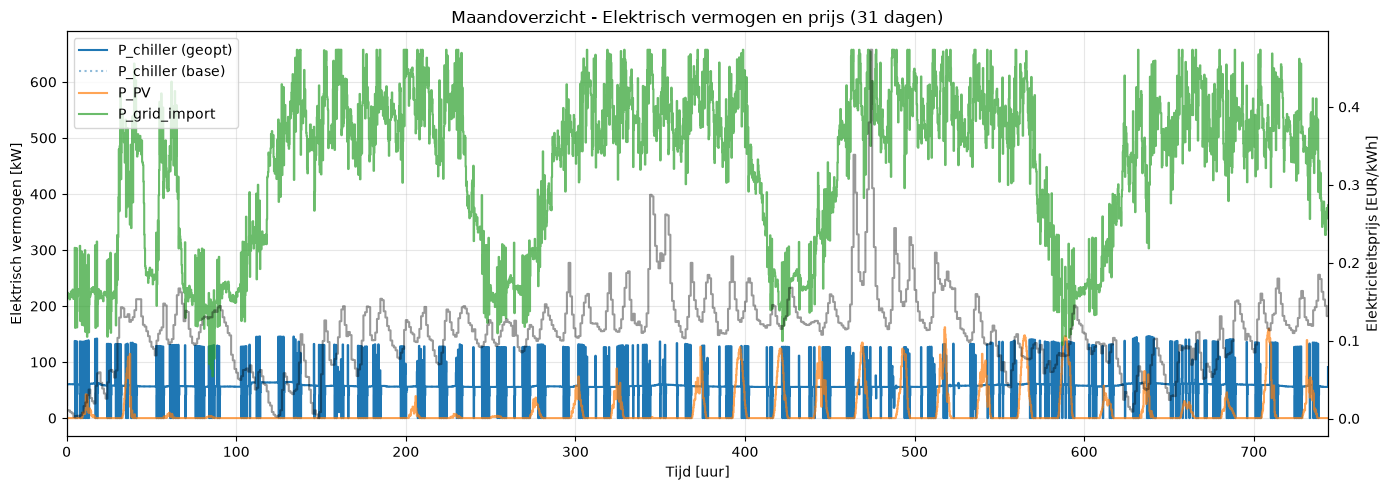

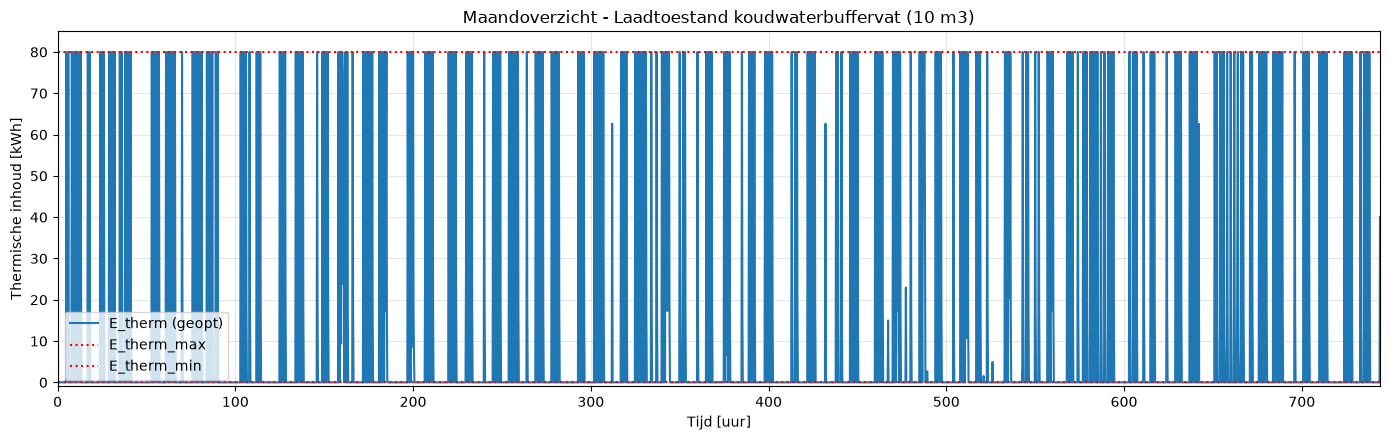

In [61]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_DAYS = 31
N_STEPS = 96 * N_DAYS  # 31 dagen = 2976 kwartieren
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur

price = df["price"].values / 1000.0  # EUR/kWh
P_pv = df["pv_production"].values  # kW
P_inflex = df["inflex_load"].values  # kW
T_outdoor = df["outdoor_temperature"].values  # degC

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. PARAMETERS
# -----------------------------------------------------------------------------
Q_demand = np.full(N_STEPS, 250)  # kW thermisch, constante proceskoeling
P_max_chiller = 250.0  # kW elektrisch

temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points)

V_buffer = 10  # m3
KWH_PER_M3 = 8.0
E_therm_max = V_buffer * KWH_PER_M3
E_therm_min = 0.0
eta_loss = 0.998
E_therm_0 = 0.5 * E_therm_max

# --- Parameters gecombineerde kostenfunctie ---
vaste_kosten = 30.7903 / 1000  # EUR/kWh, vaste opslag op geimporteerde energie
netverliesfactor = 0.0185  # fractie netverliezen

access_power = 5000  # kW, gecontracteerd vermogen
excess_prijs = 2.9975458  # EUR/kW/maand (volledig maandtarief)
piekprijs = 4.2269465  # EUR/kW/maand (volledig maandtarief)
prijs_boete = 4.4963187  # EUR/kW/maand (volledig maandtarief)


# -----------------------------------------------------------------------------
# 3. OPTIMALISATIE & BASELINE
# -----------------------------------------------------------------------------
def kosten_componenten(P_grid_import, P_grid_export, gebruik_cvxpy):
    """Berekent de drie kostencomponenten (spot, energie, piek) over de maand."""
    if gebruik_cvxpy:
        spotkosten = cp.sum(cp.multiply(P_grid_import - P_grid_export, price)) * dt
        import_spotkosten = cp.sum(cp.multiply(P_grid_import, price)) * dt

        energiekosten = (
            cp.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )

        piek = cp.max(P_grid_import)
        Ppiekbovenaccess = cp.pos(piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )
    else:
        spotkosten = np.sum((P_grid_import - P_grid_export) * price) * dt
        import_spotkosten = np.sum(P_grid_import * price) * dt

        energiekosten = (
            np.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )

        piek = np.max(P_grid_import)
        Ppiekbovenaccess = max(0.0, piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )

    return spotkosten, energiekosten, piekkosten, piek


def solve_optimized():
    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm = cp.Variable(N_STEPS + 1)

    Q_chiller = cp.multiply(COP_t, P_chiller)

    constraints = [
        P_chiller <= P_max_chiller,
        E_therm[0] == E_therm_0,
        E_therm >= E_therm_min,
        E_therm <= E_therm_max,
        E_therm[N_STEPS] == E_therm_0,
        P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
    ]

    for t in range(N_STEPS):
        constraints += [
            E_therm[t + 1]
            == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
        ]

    spotkosten, energiekosten, piekkosten, piek = kosten_componenten(
        P_grid_import, P_grid_export, gebruik_cvxpy=True
    )

    problem = cp.Problem(
        cp.Minimize(spotkosten + energiekosten + piekkosten), constraints
    )
    problem.solve()  # Gebruikt de standaard solver (bijv. CLARABEL/OSQP)

    return {
        "P_chiller": P_chiller.value,
        "P_grid_import": P_grid_import.value,
        "P_grid_export": P_grid_export.value,
        "E_therm": E_therm.value,
        "spotkosten": spotkosten.value,
        "energiekosten": energiekosten.value,
        "piekkosten": piekkosten.value,
        "piek": piek.value,
        "cost": problem.value,
    }


def solve_baseline():
    P_chiller_bl = Q_demand / COP_t
    net_bl = P_chiller_bl + P_inflex - P_pv
    P_grid_import_bl = np.maximum(net_bl, 0.0)
    P_grid_export_bl = np.maximum(-net_bl, 0.0)

    E_therm_bl = np.full(N_STEPS + 1, E_therm_0)

    spotkosten_bl, energiekosten_bl, piekkosten_bl, piek_bl = kosten_componenten(
        P_grid_import_bl, P_grid_export_bl, gebruik_cvxpy=False
    )

    return {
        "P_chiller": P_chiller_bl,
        "P_grid_import": P_grid_import_bl,
        "P_grid_export": P_grid_export_bl,
        "E_therm": E_therm_bl,
        "spotkosten": spotkosten_bl,
        "energiekosten": energiekosten_bl,
        "piekkosten": piekkosten_bl,
        "piek": piek_bl,
        "cost": spotkosten_bl + energiekosten_bl + piekkosten_bl,
    }


opt = solve_optimized()
base = solve_baseline()

# -----------------------------------------------------------------------------
# 4. KOSTENVERGELIJKING MAAND
# -----------------------------------------------------------------------------
savings_pct = 100.0 * (base["cost"] - opt["cost"]) / base["cost"]

print(f"{'':25}{'Baseline':>12}{'Geoptimaliseerd':>18}")
print("-" * 55)
print(f"{'Spotkosten [EUR]':25}{base['spotkosten']:>12.2f}{opt['spotkosten']:>18.2f}")
print(f"{'Energiekosten [EUR]':25}{base['energiekosten']:>12.2f}{opt['energiekosten']:>18.2f}")
print(f"{'Piekkosten [EUR]':25}{base['piekkosten']:>12.2f}{opt['piekkosten']:>18.2f}")
print("-" * 55)
print(f"{'Totale kosten [EUR]':25}{base['cost']:>12.2f}{opt['cost']:>18.2f}")
print("-" * 55)
print(f"{'Totale kostenbesparing':25}{'':>12}{savings_pct:>17.1f}%")
print(f"{'Gerealiseerde piek [kW]':25}{base['piek']:>12.2f}{opt['piek']:>18.2f}")

# -----------------------------------------------------------------------------
# 5. VISUALISATIES (31 DAGEN)
# -----------------------------------------------------------------------------
max_hours = N_STEPS * dt

# --- Grafiek 1: Elektrisch vermogen + prijs ---
fig1, ax1 = plt.subplots(figsize=(14, 5))
ax1.step(time_h, opt["P_chiller"], where="post", label="P_chiller (geopt)", color="tab:blue")
ax1.step(time_h, base["P_chiller"], where="post", label="P_chiller (base)", color="tab:blue", linestyle=":", alpha=0.5)
ax1.step(time_h, P_pv, where="post", label="P_PV", color="tab:orange", alpha=0.7)
ax1.step(time_h, opt["P_grid_import"], where="post", label="P_grid_import", color="tab:green", alpha=0.7)
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, max_hours)
ax1.grid(alpha=0.3)
ax1.legend(loc="upper left")

ax1b = ax1.twinx()
ax1b.step(time_h, price, where="post", color="black", alpha=0.4, label="Prijs")
ax1b.set_ylabel("Elektriciteitsprijs [EUR/kWh]")
ax1.set_title(f"Maandoverzicht - Elektrisch vermogen en prijs ({N_DAYS} dagen)")
fig1.tight_layout()
plt.show()

# --- Grafiek 2: Laadtoestand buffervat ---
fig2, ax2 = plt.subplots(figsize=(14, 4.5))
time_h_full = np.arange(N_STEPS + 1) * dt
ax2.plot(time_h_full, opt["E_therm"], label="E_therm (geopt)", color="tab:blue")
ax2.axhline(E_therm_max, color="red", linestyle=":", label="E_therm_max")
ax2.axhline(E_therm_min, color="red", linestyle=":", label="E_therm_min")
ax2.set_xlabel("Tijd [uur]")
ax2.set_ylabel("Thermische inhoud [kWh]")
ax2.set_xlim(0, max_hours)
ax2.set_ylim(-1, E_therm_max + 5)
ax2.grid(alpha=0.3)
ax2.legend(loc="best")
ax2.set_title(f"Maandoverzicht - Laadtoestand koudwaterbuffervat ({V_buffer} m3)")
fig2.tight_layout()
plt.show()

## Over heel jaar 

Start optimalisatie voor het hele jaar (dit kan even duren)...
                                     CVXPY                                     
                                     v1.9.2                                    


(CVXPY) Aug 19 02:55:49 PM: Your problem has 140161 variables, 175204 constraints, and 0 parameters.
(CVXPY) Aug 19 02:55:55 PM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Aug 19 02:55:55 PM: DCP verification time: 5.7705 seconds.
(CVXPY) Aug 19 02:55:55 PM: Expression tree has 8 nodes.
(CVXPY) Aug 19 02:55:55 PM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Aug 19 02:55:55 PM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Aug 19 02:55:55 PM: Your problem is compiled with the CPP canonicalization backend.
(CVXPY) Aug 19 02:56:01 PM: Compiling problem (target solver=CLARABEL).
(CVXPY) Aug 19 02:56:01 PM: Reduction chain: Dcp2Cone -> CvxAttr2Constr -> EliminateZeroSized -> ConeMatrixStuffing -> CLARABEL
(CVXPY) Aug 19 02:56:01 PM: Applying reduction Dcp2Cone


-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------


(CVXPY) Aug 19 02:56:13 PM: Applying reduction CvxAttr2Constr
(CVXPY) Aug 19 02:56:18 PM: Applying reduction EliminateZeroSized
(CVXPY) Aug 19 02:56:19 PM: Applying reduction ConeMatrixStuffing
(CVXPY) Aug 19 03:03:52 PM: Applying reduction CLARABEL
(CVXPY) Aug 19 03:03:56 PM: Finished problem compilation (took 4.805e+02 seconds).
(CVXPY) Aug 19 03:03:56 PM: Invoking solver CLARABEL  to obtain a solution.


-------------------------------------------------------------------------------
                                Numerical solver                               
-------------------------------------------------------------------------------
-------------------------------------------------------------
           Clarabel.rs v0.11.1  -  Clever Acronym                

                   (c) Paul Goulart                          
                University of Oxford, 2022                   
-------------------------------------------------------------

problem:
  variables     = 140163
  constraints   = 315366
  nnz(P)        = 0
  nnz(A)        = 490567
  cones (total) = 2
    :        Zero = 1,  numel = 70082
    : Nonnegative = 1,  numel = 245284

settings:
  linear algebra: direct / qdldl, precision: 64 bit (1 thread)
  max iter = 200, time limit = Inf,  max step = 0.990
  tol_feas = 1.0e-8, tol_gap_abs = 1.0e-8, tol_gap_rel = 1.0e-8,
  static reg : on, ϵ1 = 1.0e-8, ϵ2 = 4.9e-32
  dyn

(CVXPY) Aug 19 03:04:03 PM: Problem status: optimal
(CVXPY) Aug 19 03:04:03 PM: Optimal value: 6.011e+05
(CVXPY) Aug 19 03:04:03 PM: Compilation took 4.805e+02 seconds
(CVXPY) Aug 19 03:04:03 PM: Solver (including time spent in interface) took 6.114e+00 seconds


-------------------------------------------------------------------------------
                                    Summary                                    
-------------------------------------------------------------------------------

              JAARRESULTATEN (365 DAGEN)               
                             Baseline   Geoptimaliseerd
-------------------------------------------------------
Spotkosten [EUR]            289073.26         285490.83
Energiekosten [EUR]         102449.16         102432.33
Piekkosten [EUR]            214919.96         213197.02
-------------------------------------------------------
Totale kosten [EUR]         606442.38         601120.17
-------------------------------------------------------
Totale kostenbesparing                             0.9%
Gerealiseerde piek [kW]        691.34            657.37


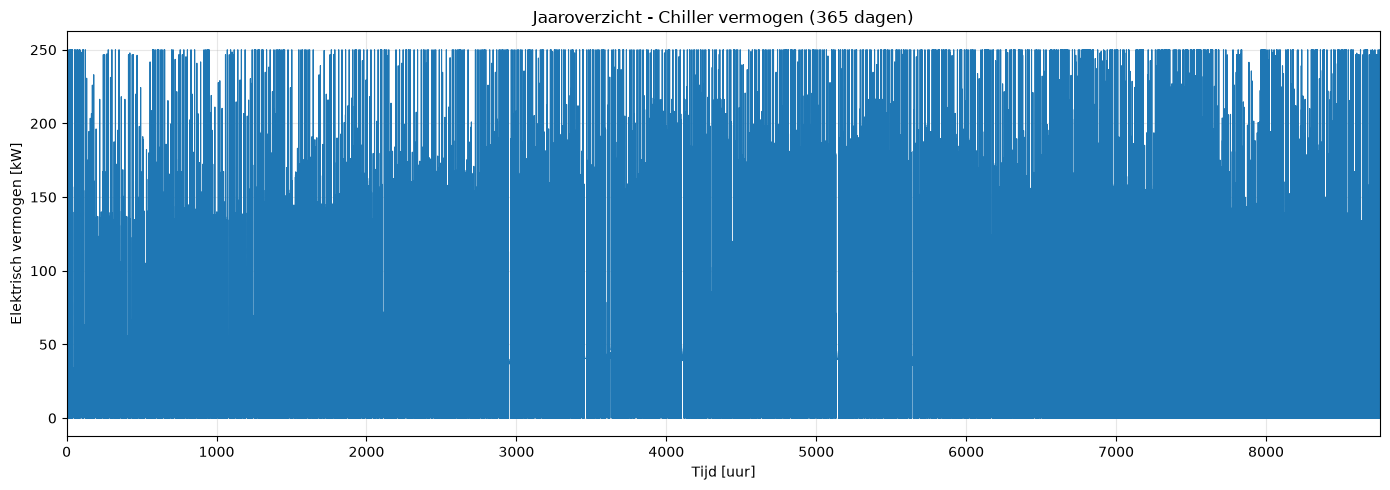

In [62]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN (JAARBASIS)
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_DAYS = 365  # 365 dagen = 35.040 kwartieren
N_STEPS = 96 * N_DAYS 

# Veiligheidscheck of de CSV genoeg data bevat voor een heel jaar
if len(df) < N_STEPS:
    print(f"Waarschuwing: CSV bevat slechts {len(df)} rijen in plaats van {N_STEPS}. Er wordt doorgerekend met de beschikbare data.")
    N_STEPS = len(df)
    N_DAYS = N_STEPS // 96

df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur

price = df["price"].values / 1000.0  # EUR/kWh
P_pv = df["pv_production"].values  # kW
P_inflex = df["inflex_load"].values  # kW
T_outdoor = df["outdoor_temperature"].values  # degC

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. PARAMETERS
# -----------------------------------------------------------------------------
Q_demand = np.full(N_STEPS, 150.0)  # kW thermisch (voorbeelwaarde, pas aan naar wens)
P_max_chiller = 250.0  # kW elektrisch

temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points)

V_buffer = 30.0  # m3 (vergroot voor jaaroptimalisatie)
KWH_PER_M3 = 8.0
E_therm_max = V_buffer * KWH_PER_M3
E_therm_min = 0.0
eta_loss = 0.998
E_therm_0 = 0.5 * E_therm_max

# --- Parameters gecombineerde kostenfunctie ---
vaste_kosten = 30.7903 / 1000  # EUR/kWh, vaste opslag op geimporteerde energie
netverliesfactor = 0.0185  # fractie netverliezen

access_power = 5000  # kW, gecontracteerd vermogen
# Let op: Als de tarieven per maand gelden en je optimaliseert 12 maanden in één keer,
# vermenigvuldig je dit vaak met 12 of pas je de piekberekening per maand toe.
excess_prijs = 2.9975458 * 12  # Omgezet naar jaartarief (of jaartarief direct invullen)
piekprijs = 4.2269465 * 12      # Omgezet naar jaartarief
prijs_boete = 4.4963187 * 12    # Omgezet naar jaartarief


# -----------------------------------------------------------------------------
# 3. OPTIMALISATIE & BASELINE
# -----------------------------------------------------------------------------
def kosten_componenten(P_grid_import, P_grid_export, gebruik_cvxpy):
    """Berekent de drie kostencomponenten (spot, energie, piek) over het hele jaar."""
    if gebruik_cvxpy:
        spotkosten = cp.sum(cp.multiply(P_grid_import - P_grid_export, price)) * dt
        import_spotkosten = cp.sum(cp.multiply(P_grid_import, price)) * dt

        energiekosten = (
            cp.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )

        piek = cp.max(P_grid_import)
        Ppiekbovenaccess = cp.pos(piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )
    else:
        spotkosten = np.sum((P_grid_import - P_grid_export) * price) * dt
        import_spotkosten = np.sum(P_grid_import * price) * dt

        energiekosten = (
            np.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )

        piek = np.max(P_grid_import)
        Ppiekbovenaccess = max(0.0, piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )

    return spotkosten, energiekosten, piekkosten, piek


def solve_optimized():
    print("Start optimalisatie voor het hele jaar (dit kan even duren)...")
    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm = cp.Variable(N_STEPS + 1)

    Q_chiller = cp.multiply(COP_t, P_chiller)

    constraints = [
        P_chiller <= P_max_chiller,
        E_therm[0] == E_therm_0,
        E_therm >= E_therm_min,
        E_therm <= E_therm_max,
        E_therm[N_STEPS] == E_therm_0,
        P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
    ]

    for t in range(N_STEPS):
        constraints += [
            E_therm[t + 1]
            == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
        ]

    spotkosten, energiekosten, piekkosten, piek = kosten_componenten(
        P_grid_import, P_grid_export, gebruik_cvxpy=True
    )

    problem = cp.Problem(
        cp.Minimize(spotkosten + energiekosten + piekkosten), constraints
    )
    
    # Voor grote problemen van 1 jaar is een snelle solver zoals CLARABEL of OSQP handig
    problem.solve(solver=cp.CLARABEL, verbose=True)

    return {
        "P_chiller": P_chiller.value,
        "P_grid_import": P_grid_import.value,
        "P_grid_export": P_grid_export.value,
        "E_therm": E_therm.value,
        "spotkosten": spotkosten.value,
        "energiekosten": energiekosten.value,
        "piekkosten": piekkosten.value,
        "piek": piek.value,
        "cost": problem.value,
    }


def solve_baseline():
    P_chiller_bl = Q_demand / COP_t
    net_bl = P_chiller_bl + P_inflex - P_pv
    P_grid_import_bl = np.maximum(net_bl, 0.0)
    P_grid_export_bl = np.maximum(-net_bl, 0.0)

    E_therm_bl = np.full(N_STEPS + 1, E_therm_0)

    spotkosten_bl, energiekosten_bl, piekkosten_bl, piek_bl = kosten_componenten(
        P_grid_import_bl, P_grid_export_bl, gebruik_cvxpy=False
    )

    return {
        "P_chiller": P_chiller_bl,
        "P_grid_import": P_grid_import_bl,
        "P_grid_export": P_grid_export_bl,
        "E_therm": E_therm_bl,
        "spotkosten": spotkosten_bl,
        "energiekosten": energiekosten_bl,
        "piekkosten": piekkosten_bl,
        "piek": piek_bl,
        "cost": spotkosten_bl + energiekosten_bl + piekkosten_bl,
    }


opt = solve_optimized()
base = solve_baseline()

# -----------------------------------------------------------------------------
# 4. KOSTENVERGELIJKING JAARBASIS
# -----------------------------------------------------------------------------
savings_pct = 100.0 * (base["cost"] - opt["cost"]) / base["cost"]

print("\n" + "="*55)
print(f"{'JAARRESULTATEN (365 DAGEN)':^55}")
print("="*55)
print(f"{'':25}{'Baseline':>12}{'Geoptimaliseerd':>18}")
print("-" * 55)
print(f"{'Spotkosten [EUR]':25}{base['spotkosten']:>12.2f}{opt['spotkosten']:>18.2f}")
print(f"{'Energiekosten [EUR]':25}{base['energiekosten']:>12.2f}{opt['energiekosten']:>18.2f}")
print(f"{'Piekkosten [EUR]':25}{base['piekkosten']:>12.2f}{opt['piekkosten']:>18.2f}")
print("-" * 55)
print(f"{'Totale kosten [EUR]':25}{base['cost']:>12.2f}{opt['cost']:>18.2f}")
print("-" * 55)
print(f"{'Totale kostenbesparing':25}{'':>12}{savings_pct:>17.1f}%")
print(f"{'Gerealiseerde piek [kW]':25}{base['piek']:>12.2f}{opt['piek']:>18.2f}")

# -----------------------------------------------------------------------------
# 5. VISUALISATIES (JAAROVERZICHT)
# -----------------------------------------------------------------------------
max_hours = N_STEPS * dt

fig1, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(time_h, opt["P_chiller"], label="P_chiller (geopt)", color="tab:blue", linewidth=0.8)
ax1.set_xlabel("Tijd [uur]")
ax1.set_ylabel("Elektrisch vermogen [kW]")
ax1.set_xlim(0, max_hours)
ax1.grid(alpha=0.3)
ax1.set_title(f"Jaaroverzicht - Chiller vermogen ({N_DAYS} dagen)")
fig1.tight_layout()
plt.show()

## ideaal buffergrote bepalen

Basislijn berekenen...

Start optimalisatie voor verschillende buffervolgrootten...
 > Berekenen voor V_buffer = 2 m3...
 > Berekenen voor V_buffer = 5 m3...
 > Berekenen voor V_buffer = 10 m3...
 > Berekenen voor V_buffer = 20 m3...
 > Berekenen voor V_buffer = 35 m3...
 > Berekenen voor V_buffer = 50 m3...
 > Berekenen voor V_buffer = 75 m3...
 > Berekenen voor V_buffer = 100 m3...

               BUFFER SWEEP RESULTATEN (31 DAGEN)                
Inhoud [m3]    Totale Kosten [EUR] Besparing t.o.v. Base [%]
-----------------------------------------------------------------
Baseline (0)   67754.13            0.0%                     
2              67677.46            0.1                      %
5              67562.74            0.3                      %
10             67438.62            0.5                      %
20             67364.07            0.6                      %
35             67259.88            0.7                      %
50             67170.36            0.9          

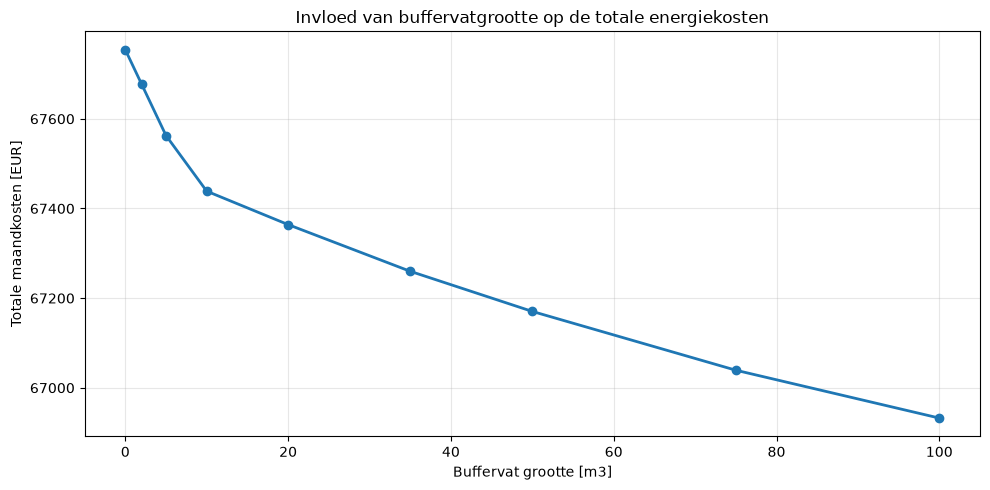

In [63]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_DAYS = 31
N_STEPS = 96 * N_DAYS  # 31 dagen = 2976 kwartieren
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur

price = df["price"].values / 1000.0  # EUR/kWh
P_pv = df["pv_production"].values  # kW
P_inflex = df["inflex_load"].values  # kW
T_outdoor = df["outdoor_temperature"].values  # degC

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. PARAMETERS
# -----------------------------------------------------------------------------
Q_demand = np.full(N_STEPS, 250.0)  # kW thermisch, constante proceskoeling
P_max_chiller = 250.0  # kW elektrisch

temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points)

KWH_PER_M3 = 8.0
eta_loss = 0.998

# Te testen buffervolgrootten in kubieke meters (m3)
buffer_sizes = [2, 5, 10, 20, 35, 50, 75, 100]

# --- Parameters gecombineerde kostenfunctie ---
vaste_kosten = 30.7903 / 1000  # EUR/kWh, vaste opslag op geimporteerde energie
netverliesfactor = 0.0185  # fractie netverliezen

access_power = 5000  # kW, gecontracteerd vermogen
excess_prijs = 2.9975458  # EUR/kW/maand (volledig maandtarief)
piekprijs = 4.2269465  # EUR/kW/maand (volledig maandtarief)
prijs_boete = 4.4963187  # EUR/kW/maand (volledig maandtarief)


# -----------------------------------------------------------------------------
# 3. KOSTENFUNCTIE & OPTIMALISATIE PER BUFFERGROOTTE
# -----------------------------------------------------------------------------
def kosten_componenten(P_grid_import, P_grid_export, gebruik_cvxpy):
    """Berekent de drie kostencomponenten (spot, energie, piek) over de maand."""
    if gebruik_cvxpy:
        spotkosten = cp.sum(cp.multiply(P_grid_import - P_grid_export, price)) * dt
        import_spotkosten = cp.sum(cp.multiply(P_grid_import, price)) * dt

        energiekosten = (
            cp.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )

        piek = cp.max(P_grid_import)
        Ppiekbovenaccess = cp.pos(piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )
    else:
        spotkosten = np.sum((P_grid_import - P_grid_export) * price) * dt
        import_spotkosten = np.sum(P_grid_import * price) * dt

        energiekosten = (
            np.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )

        piek = np.max(P_grid_import)
        Ppiekbovenaccess = max(0.0, piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )

    return spotkosten, energiekosten, piekkosten, piek


def solve_optimized(V_buffer):
    E_therm_max = V_buffer * KWH_PER_M3
    E_therm_min = 0.0
    E_therm_0 = 0.5 * E_therm_max

    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm = cp.Variable(N_STEPS + 1)

    Q_chiller = cp.multiply(COP_t, P_chiller)

    constraints = [
        P_chiller <= P_max_chiller,
        E_therm[0] == E_therm_0,
        E_therm >= E_therm_min,
        E_therm <= E_therm_max,
        E_therm[N_STEPS] == E_therm_0,
        P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
    ]

    for t in range(N_STEPS):
        constraints += [
            E_therm[t + 1]
            == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
        ]

    spotkosten, energiekosten, piekkosten, piek = kosten_componenten(
        P_grid_import, P_grid_export, gebruik_cvxpy=True
    )

    problem = cp.Problem(
        cp.Minimize(spotkosten + energiekosten + piekkosten), constraints
    )
    problem.solve()

    return {
        "cost": problem.value,
        "spotkosten": spotkosten.value,
        "energiekosten": energiekosten.value,
        "piekkosten": piekkosten.value,
        "piek": piek.value,
    }


def solve_baseline():
    P_chiller_bl = Q_demand / COP_t
    net_bl = P_chiller_bl + P_inflex - P_pv
    P_grid_import_bl = np.maximum(net_bl, 0.0)
    P_grid_export_bl = np.maximum(-net_bl, 0.0)
    E_therm_bl = np.full(N_STEPS + 1, 0.0)

    spotkosten_bl, energiekosten_bl, piekkosten_bl, piek_bl = kosten_componenten(
        P_grid_import_bl, P_grid_export_bl, gebruik_cvxpy=False
    )

    return {
        "cost": spotkosten_bl + energiekosten_bl + piekkosten_bl,
        "piek": piek_bl,
    }


# -----------------------------------------------------------------------------
# 4. UITVOEREN PARAMETER SWEEP
# -----------------------------------------------------------------------------
print("Basislijn berekenen...")
base = solve_baseline()

results = []
print("\nStart optimalisatie voor verschillende buffervolgrootten...")
for V in buffer_sizes:
    print(f" > Berekenen voor V_buffer = {V} m3...")
    res = solve_optimized(V)
    res["V_buffer"] = V
    results.append(res)

# -----------------------------------------------------------------------------
# 5. RESULTATEN WEERGEVEN & PLOTTEN
# -----------------------------------------------------------------------------
print("\n" + "="*65)
print(f"{'BUFFER SWEEP RESULTATEN (31 DAGEN)':^65}")
print("="*65)
print(f"{'Inhoud [m3]':<15}{'Totale Kosten [EUR]':<20}{'Besparing t.o.v. Base [%]':<25}")
print("-" * 65)

print(f"{'Baseline (0)':<15}{base['cost']:<20.2f}{'0.0%':<25}")
costs_list = [base['cost']]
volumes_plot = [0] + buffer_sizes

for r in results:
    saving = 100.0 * (base["cost"] - r["cost"]) / base["cost"]
    print(f"{r['V_buffer']:<15}{r['cost']:<20.2f}{saving:<25.1f}%")
    costs_list.append(r["cost"])

print("="*65)

# --- Grafiek van kosten vs buffervatgrootte ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(volumes_plot, costs_list, marker="o", linestyle="-", color="tab:blue", linewidth=2)
ax.set_xlabel("Buffervat grootte [m3]")
ax.set_ylabel("Totale maandkosten [EUR]")
ax.set_title("Invloed van buffervatgrootte op de totale energiekosten")
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

In [66]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# 1. DATA INLEZEN EN VOORBEREIDEN
# -----------------------------------------------------------------------------
CSV_PATH = "plant1.csv"

df = pd.read_csv(CSV_PATH, parse_dates=["timestamp"])

N_DAYS = 31
N_STEPS = 96 * N_DAYS  # 31 dagen = 2976 kwartieren
df = df.iloc[:N_STEPS].reset_index(drop=True)

dt = 0.25  # uur

price = df["price"].values / 1000.0  # EUR/kWh
P_pv = df["pv_production"].values  # kW
P_inflex = df["inflex_load"].values  # kW
T_outdoor = df["outdoor_temperature"].values  # degC

time_h = np.arange(N_STEPS) * dt

# -----------------------------------------------------------------------------
# 2. PARAMETERS & BUSINESSCASE UITGANGSPUNTEN
# -----------------------------------------------------------------------------
Q_demand = np.full(N_STEPS, 250.0)  # kW thermisch, constante proceskoeling
P_max_chiller = 250.0  # kW elektrisch

temp_points = [0, 5, 10, 15, 20, 25, 30]
cop_points = [4.5, 4.3, 4.0, 3.7, 3.4, 3.1, 2.8]
COP_t = np.interp(T_outdoor, temp_points, cop_points)

KWH_PER_M3 = 8.0
eta_loss = 0.998

# Te testen buffervolgrootten in kubieke meters (m3)
buffer_sizes = [2, 5, 10, 20, 35, 50, 75, 100]

# Financiële parameters voor de NPV-analyse
KOSTEN_PER_M3 = 800.0  # EUR per m3 geïnstalleerd buffervat
LEVENSDUUR = 20  # Jaren
DISCONTERINGSVOET = 0.10  # 10% rente/kapitaatskosten
OPEX_PCT = 0.01  # 1% van de CAPEX per jaar aan onderhoud

# --- Parameters gecombineerde kostenfunctie ---
vaste_kosten = 30.7903 / 1000  # EUR/kWh, vaste opslag op geimporteerde energie
netverliesfactor = 0.0185  # fractie netverliezen

access_power = 5000  # kW, gecontracteerd vermogen
excess_prijs = 2.9975458  # EUR/kW/maand (volledig maandtarief)
piekprijs = 4.2269465  # EUR/kW/maand (volledig maandtarief)
prijs_boete = 4.4963187  # EUR/kW/maand (volledig maandtarief)


# -----------------------------------------------------------------------------
# 3. KOSTENFUNCTIE & OPTIMALISATIE PER BUFFERGROOTTE
# -----------------------------------------------------------------------------
def kosten_componenten(P_grid_import, P_grid_export, gebruik_cvxpy):
    if gebruik_cvxpy:
        spotkosten = cp.sum(cp.multiply(P_grid_import - P_grid_export, price)) * dt
        import_spotkosten = cp.sum(cp.multiply(P_grid_import, price)) * dt
        energiekosten = (
            cp.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )
        piek = cp.max(P_grid_import)
        Ppiekbovenaccess = cp.pos(piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )
    else:
        spotkosten = np.sum((P_grid_import - P_grid_export) * price) * dt
        import_spotkosten = np.sum(P_grid_import * price) * dt
        energiekosten = (
            np.sum(vaste_kosten * P_grid_import) * dt
            + netverliesfactor * import_spotkosten
        )
        piek = np.max(P_grid_import)
        Ppiekbovenaccess = max(0.0, piek - access_power)
        piekkosten = (
            access_power * excess_prijs
            + piek * piekprijs
            + Ppiekbovenaccess * prijs_boete
        )
    return spotkosten, energiekosten, piekkosten, piek


def solve_optimized(V_buffer):
    E_therm_max = V_buffer * KWH_PER_M3
    E_therm_min = 0.0
    E_therm_0 = 0.5 * E_therm_max

    P_chiller = cp.Variable(N_STEPS, nonneg=True)
    P_grid_import = cp.Variable(N_STEPS, nonneg=True)
    P_grid_export = cp.Variable(N_STEPS, nonneg=True)
    E_therm = cp.Variable(N_STEPS + 1)

    Q_chiller = cp.multiply(COP_t, P_chiller)

    constraints = [
        P_chiller <= P_max_chiller,
        E_therm[0] == E_therm_0,
        E_therm >= E_therm_min,
        E_therm <= E_therm_max,
        E_therm[N_STEPS] == E_therm_0,
        P_pv + P_grid_import == P_chiller + P_inflex + P_grid_export,
    ]

    for t in range(N_STEPS):
        constraints += [
            E_therm[t + 1]
            == eta_loss * E_therm[t] + (Q_chiller[t] - Q_demand[t]) * dt
        ]

    spotkosten, energiekosten, piekkosten, piek = kosten_componenten(
        P_grid_import, P_grid_export, gebruik_cvxpy=True
    )

    problem = cp.Problem(
        cp.Minimize(spotkosten + energiekosten + piekkosten), constraints
    )
    problem.solve()

    return {
        "cost": problem.value,
        "piek": piek.value,
    }


def solve_baseline():
    P_chiller_bl = Q_demand / COP_t
    net_bl = P_chiller_bl + P_inflex - P_pv
    P_grid_import_bl = np.maximum(net_bl, 0.0)
    P_grid_export_bl = np.maximum(-net_bl, 0.0)
    
    spotkosten_bl, energiekosten_bl, piekkosten_bl, piek_bl = kosten_componenten(
        P_grid_import_bl, P_grid_export_bl, gebruik_cvxpy=False
    )
    return {
        "cost": spotkosten_bl + energiekosten_bl + piekkosten_bl,
        "piek": piek_bl,
    }


# -----------------------------------------------------------------------------
# 4. UITVOEREN SWEEP & NPV BEREKENING
# -----------------------------------------------------------------------------
print("Basislijn berekenen...")
base = solve_baseline()

results = []
print("\nStart optimalisatie en NPV-analyse per buffervatgrootte...")

for V in buffer_sizes:
    print(f" > Doorrekenen voor V_buffer = {V} m3...")
    res = solve_optimized(V)
    
    # Financiële basisberekening
    maand_besparing = base["cost"] - res["cost"]
    jaar_besparing = maand_besparing * 12
    capex = V * KOSTEN_PER_M3
    jaar_opex = capex * OPEX_PCT
    netto_jaar_kasstroom = jaar_besparing - jaar_opex
    
    # NPV berekening over de ingestelde levensduur en disconteringsvoet
    npv = -capex
    for jaar in range(1, LEVENSDUUR + 1):
        npv += netto_jaar_kasstroom / ((1.0 + DISCONTERINGSVOET) ** jaar)
        
    # Terugverdientijd (eenvoudig)
    if netto_jaar_kasstroom > 0:
        terugverdientijd = capex / netto_jaar_kasstroom
    else:
        terugverdientijd = float('inf')
        
    results.append({
        "V_buffer": V,
        "capex": capex,
        "jaar_besparing": jaar_besparing,
        "netto_kasstroom": netto_jaar_kasstroom,
        "terugverdientijd": terugverdientijd,
        "npv": npv
    })

# -----------------------------------------------------------------------------
# 5. OVERZICHT PRINTEN
# -----------------------------------------------------------------------------
# -----------------------------------------------------------------------------
# 5. OVERZICHT PRINTEN
# -----------------------------------------------------------------------------
print("\n" + "="*95)
print(f"{'FINANCIEEL OVERZICHT & NPV ANALYSE (20 JAAR, 10% RENTE)':^95}")
print("="*95)
print(f"{'Inhoud [m3]':<12}{'CAPEX':<15}{'Jaarbesparing':<16}{'Terugverdientijd':<18}{'NPV [EUR]':<20}")
print("-" * 95)

beste_optie = None
max_npv = -float('inf')

for r in results:
    if r["npv"] > max_npv:
        max_npv = r["npv"]
        beste_optie = r
        
    print(f"{r['V_buffer']:<12}€ {r['capex']:<13,.0f}€ {r['jaar_besparing']:<14,.0f}{r['terugverdientijd']:<18.1f} jaar€ {r['npv']:<18,.0f}")

print("="*95)
if beste_optie:
    print(f"\n💡 CONCLUSIE OP BASIS VAN NPV (MEEST ECONOMISCHE WAARDE):")
    print(f"   De meest winstgevende buffervatgrootte over {LEVENSDUUR} jaar is **{beste_optie['V_buffer']} m³**.")
    print(f"   - Totale investering (CAPEX): € {beste_optie['capex']:,.0f}")
    print(f"   - Netto Contante Waarde (NPV): **€ {beste_optie['npv']:,.0f}**")
    print(f"   - Terugverdientijd:          {beste_optie['terugverdientijd']:.1f} jaar")
print("="*95)

Basislijn berekenen...

Start optimalisatie en NPV-analyse per buffervatgrootte...
 > Doorrekenen voor V_buffer = 2 m3...
 > Doorrekenen voor V_buffer = 5 m3...
 > Doorrekenen voor V_buffer = 10 m3...
 > Doorrekenen voor V_buffer = 20 m3...
 > Doorrekenen voor V_buffer = 35 m3...
 > Doorrekenen voor V_buffer = 50 m3...
 > Doorrekenen voor V_buffer = 75 m3...
 > Doorrekenen voor V_buffer = 100 m3...

                    FINANCIEEL OVERZICHT & NPV ANALYSE (20 JAAR, 10% RENTE)                    
Inhoud [m3] CAPEX          Jaarbesparing   Terugverdientijd  NPV [EUR]           
-----------------------------------------------------------------------------------------------
2           € 1,600        € 920           1.8                jaar€ 6,097             
5           € 4,000        € 2,297         1.8                jaar€ 15,213            
10          € 8,000        € 3,786         2.2                jaar€ 23,553            
20          € 16,000       € 4,681         3.5                